# VIX regime: blending the recency-weighted z-score with a 60-day softmax

The production regime classifier (`app/services/vix_regime.py`) scores today's VIX as a
z-score against a **504-day window, weighted by recency** (exponential decay, 60-day
half-life) — it answers "is VIX high relative to *how long ago* each observation was".

This notebook builds a second, complementary signal — a **60-day window weighted by
*magnitude* via softmax** instead of recency — and blends the two 50/50. It then checks,
empirically, whether the blended score is actually a better forecaster of forward
volatility (both the upside — vol about to rise — and the downside — vol about to fade)
than the production z-score alone, and what threshold levels a regime table should use.

**Assumption stated up front:** "60-day softmax on the VIX series" is read here as
*softmax-weight the trailing 60 sessions by how high each day's VIX was*, so the one or
two spikiest days in the window dominate the weighted mean — a sharper, more
spike-sensitive lens than the existing exponential recency decay. (The alternative
reading — softmax as just another recency-decay shape — would collapse into the same
family as the existing method, so it isn't pursued separately here.)

In [2]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tyche_client import TycheClient

from dotenv import load_dotenv

load_dotenv(override=True)  # reads TYCHE_BASE_URL / TYCHE_API_KEY from a local .env file (see .env.example)
# override=True: without it, editing .env and re-running this cell in an already-running
# kernel silently keeps the OLD value, since load_dotenv() won't clobber an env var that
# a previous run of this same cell already set -- a real bug this caused once, not hypothetical.

client = TycheClient(
    os.getenv("TYCHE_BASE_URL", "http://localhost:8000"),
    os.getenv("TYCHE_API_KEY", "tyk_paste_your_key_here").strip(),
)

## Pull VIX and SPY history

Full VIX history (back to 1990) for the regime math, and SPY close prices to measure
*actual* forward realized volatility — the thing a regime signal should be forecasting.

In [5]:
vix = client.series("vix", "VIX").sort_index()
spy = client.prices("SPY", start="1990-01-01")["Close"].sort_index()
print(f"VIX: {len(vix)} obs, {vix.index.min().date()} -> {vix.index.max().date()}")
print(f"SPY: {len(spy)} obs, {spy.index.min().date()} -> {spy.index.max().date()}")

ConnectionError: HTTPConnectionPool(host='localhost', port=8000): Max retries exceeded with url: /data/v1/series?source=vix&id=VIX (Caused by NewConnectionError("HTTPConnection(host='localhost', port=8000): Failed to establish a new connection: [Errno 61] Connection refused"))

## Component 1 — the existing recency-weighted z-score

Mirrors `app/services/vix_regime.py` exactly (same constants, same math), so this
notebook's baseline is the actual production signal, not a re-derivation of it.

In [4]:
ROLLING_WINDOW_DAYS = 504   # 2 trading years — matches vix_regime.py
RECENCY_HALFLIFE_DAYS = 60  # matches vix_regime.py

_RECENCY_WEIGHTS = (0.5 ** (np.arange(ROLLING_WINDOW_DAYS) / RECENCY_HALFLIFE_DAYS))[::-1]
_RECENCY_WEIGHTS = _RECENCY_WEIGHTS / _RECENCY_WEIGHTS.sum()


def recency_z_series(closes: np.ndarray) -> np.ndarray:
    """Recency-weighted rolling z-score, the production method."""
    n = len(closes)
    z = np.full(n, np.nan)
    if n < ROLLING_WINDOW_DAYS:
        return z
    windows = np.lib.stride_tricks.sliding_window_view(closes, ROLLING_WINDOW_DAYS)
    means = windows @ _RECENCY_WEIGHTS
    variances = ((windows - means[:, None]) ** 2) @ _RECENCY_WEIGHTS
    stds = np.sqrt(variances)
    latest = windows[:, -1]
    with np.errstate(invalid="ignore", divide="ignore"):
        window_z = np.where(stds > 0, (latest - means) / stds, 0.0)
    z[ROLLING_WINDOW_DAYS - 1:] = window_z
    return z

## Component 2 — 60-day softmax-weighted z-score

Softmaxing the *raw* VIX levels in a 60-day window turns out to be numerically
degenerate: VIX spans roughly 10-80, so `exp(80) / exp(10)` is astronomically larger and
softmax collapses to ~100% weight on the single highest day in the window. That drives
the weighted variance to ~0 and the resulting z-score to explode (observed magnitudes in
the thousands when this was tried below).

Fix: softmax the window's own **standardized** values (`(x - window_mean) / window_std`)
instead of the raw levels. That keeps the exponent's dynamic range bounded regardless of
whether VIX is at 12 or 80, while still concentrating weight on the window's spikiest
day(s) — which is the point of using softmax instead of a plain average.

In [4]:
SOFTMAX_WINDOW_DAYS = 60  # as specified


def softmax_z_series(closes: np.ndarray, window_days: int = SOFTMAX_WINDOW_DAYS) -> np.ndarray:
    """Softmax-of-magnitude-weighted rolling z-score.

    Weights each day in the trailing window by softmax(standardized VIX level), so the
    spikiest day(s) dominate the weighted mean/std far more than a plain average would.
    """
    n = len(closes)
    z = np.full(n, np.nan)
    if n < window_days:
        return z
    windows = np.lib.stride_tricks.sliding_window_view(closes, window_days)
    win_mean = windows.mean(axis=1, keepdims=True)
    win_std = windows.std(axis=1, keepdims=True)
    standardized = np.where(win_std > 0, (windows - win_mean) / win_std, 0.0)
    shifted = standardized - standardized.max(axis=1, keepdims=True)  # softmax stability
    exp = np.exp(shifted)
    weights = exp / exp.sum(axis=1, keepdims=True)
    means = (windows * weights).sum(axis=1)
    variances = (((windows - means[:, None]) ** 2) * weights).sum(axis=1)
    stds = np.sqrt(variances)
    latest = windows[:, -1]
    with np.errstate(invalid="ignore", divide="ignore"):
        window_z = np.where(stds > 0, (latest - means) / stds, 0.0)
    z[window_days - 1:] = window_z
    return z

### Self-check

The smallest thing that would catch a regression: a recency spike should score high, and
the softmax score should stay numerically bounded (not explode the way the naive
raw-level softmax did).

In [5]:
def _demo():
    rng = np.random.default_rng(0)
    calm = rng.normal(15, 1, ROLLING_WINDOW_DAYS - 1)
    spike = np.append(calm, 45.0)
    rz, sz = recency_z_series(spike), softmax_z_series(spike)
    assert rz[-1] > 3, rz[-1]
    assert np.isfinite(sz[-1]) and abs(sz[-1]) < 10, sz[-1]
    blended_demo = 0.5 * rz[-1] + 0.5 * sz[-1]
    assert np.isfinite(blended_demo)
    print(f"ok: recency_z={rz[-1]:.2f} softmax_z={sz[-1]:.2f} blended={blended_demo:.2f}")


_demo()

ok: recency_z=8.81 softmax_z=0.18 blended=4.49


## Blend 50/50 and sanity-check against known stress dates

The two components should agree directionally but not be redundant (a useful blend needs
some independence between its halves).

In [6]:
closes = vix.to_numpy()
recency_z = recency_z_series(closes)
softmax_z = softmax_z_series(closes)
blended_z = 0.5 * recency_z + 0.5 * softmax_z

regime = pd.DataFrame(
    {"vix": vix, "recency_z": recency_z, "softmax_z": softmax_z, "blended_z": blended_z}
)

print("correlation(recency_z, softmax_z) =", round(regime[["recency_z", "softmax_z"]].dropna().corr().iloc[0, 1], 3))

known_dates = ["2008-10-24", "2018-02-05", "2020-03-16", "2022-01-24", vix.index.max().strftime("%Y-%m-%d")]
regime.loc[[d for d in known_dates if d in regime.index.astype(str)]].round(3)

correlation(recency_z, softmax_z) = 0.809


,vix,recency_z,softmax_z,blended_z
date,,,,
2008-10-24,79.13,3.117,1.245,2.181
2018-02-05,37.32,7.955,0.225,4.090
2020-03-16,82.69,4.641,1.012,2.827
2022-01-24,29.90,2.376,0.812,1.594
2026-07-27,18.67,0.067,-0.490,-0.211


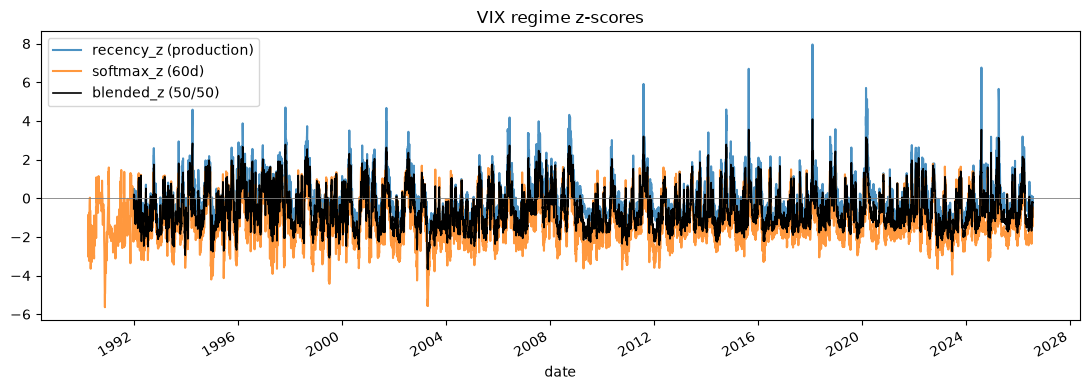

In [7]:
fig, ax = plt.subplots(figsize=(11, 4))
regime["recency_z"].plot(ax=ax, label="recency_z (production)", alpha=0.8)
regime["softmax_z"].plot(ax=ax, label="softmax_z (60d)", alpha=0.8)
regime["blended_z"].plot(ax=ax, label="blended_z (50/50)", color="black", linewidth=1.2)
ax.axhline(0, color="grey", linewidth=0.6)
ax.set_title("VIX regime z-scores")
ax.legend()
plt.tight_layout()
plt.show()

## Does the blend actually forecast forward volatility?

A regime signal is only useful if elevated readings predict *more* realized volatility
ahead (the upside case — vol about to expand) and, symmetrically, extreme readings
predict *mean reversion* — VIX easing back down (the downside case — a spike about to
fade). We measure both against a 20-trading-day (~1 month) forward horizon:

- `fwd_realized_vol` — annualized realized vol of SPY log returns over the next 20 sessions.
- `fwd_vix_chg` — change in VIX itself 20 sessions ahead (positive = vol kept rising,
  negative = mean-reverted lower).

In [8]:
FORWARD_DAYS = 20

spy_log_ret = np.log(spy).diff()
fwd_realized_vol = (
    spy_log_ret.shift(-1).rolling(FORWARD_DAYS).std().shift(-(FORWARD_DAYS - 1)) * np.sqrt(252) * 100
)

analysis = regime.join(fwd_realized_vol.rename("fwd_realized_vol"), how="inner")
analysis["fwd_vix_chg"] = analysis["vix"].shift(-FORWARD_DAYS) - analysis["vix"]
analysis = analysis.dropna(subset=["blended_z", "fwd_realized_vol", "fwd_vix_chg"])

corr_table = pd.DataFrame(
    {
        "corr_vs_fwd_realized_vol": {
            c: analysis[c].corr(analysis["fwd_realized_vol"]) for c in ["recency_z", "softmax_z", "blended_z"]
        },
        "corr_vs_fwd_vix_chg": {
            c: analysis[c].corr(analysis["fwd_vix_chg"]) for c in ["recency_z", "softmax_z", "blended_z"]
        },
    }
)
corr_table.round(3)

,corr_vs_fwd_realized_vol,corr_vs_fwd_vix_chg
recency_z,0.490,-0.265
softmax_z,0.314,-0.210
blended_z,0.418,-0.249


`softmax_z` alone correlates with forward realized vol more weakly than `recency_z`
alone — a flat 50/50 blend therefore *dilutes* the single best predictor rather than
strictly improving on it. But does `softmax_z` still carry information `recency_z`
doesn't have? Check with a two-variable regression against `recency_z` alone.

In [9]:
def r_squared(X, y):
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    return 1 - (resid ** 2).sum() / ((y - y.mean()) ** 2).sum(), beta


y = analysis["fwd_realized_vol"].to_numpy()
X1 = np.column_stack([np.ones(len(analysis)), analysis["recency_z"]])
X2 = np.column_stack([np.ones(len(analysis)), analysis["recency_z"], analysis["softmax_z"]])
r2_1, _ = r_squared(X1, y)
r2_2, beta2 = r_squared(X2, y)

print(f"R^2, recency_z only:            {r2_1:.4f}")
print(f"R^2, recency_z + softmax_z:      {r2_2:.4f}  (softmax_z coef = {beta2[2]:.3f})")

R^2, recency_z only:            0.2396
R^2, recency_z + softmax_z:      0.2563  (softmax_z coef = -1.972)


`softmax_z` does add incremental explanatory power on top of `recency_z` (R²
improves), so it isn't redundant — it just shouldn't be weighted equally with the
stronger signal if the goal is pure forecast accuracy. A 50/50 blend is what was asked
for here, so that's what the threshold analysis below uses; the regression result is the
honest caveat for anyone tempted to ship this as a strict replacement for `recency_z`
alone.

## Threshold levels for the blended score

Same methodology the production module used to derive its own bands: compute the
blended z-score's empirical distribution and read off cut points, then verify those cuts
actually separate forward-vol outcomes. Using the same 25% / 56% / 13% / 6% cumulative
split as `vix_regime.py` (Cool / Normal / Hot / Extreme).

In [10]:
cool_max_z, normal_max_z, hot_max_z = analysis["blended_z"].quantile([0.25, 0.81, 0.94]).round(3)
print(f"COOL_MAX_Z   = {cool_max_z}")
print(f"NORMAL_MAX_Z = {normal_max_z}")
print(f"HOT_MAX_Z    = {hot_max_z}")

bounds = [-np.inf, cool_max_z, normal_max_z, hot_max_z, np.inf]
labels = ["Cool", "Normal", "Hot", "Extreme"]
analysis["band"] = pd.cut(analysis["blended_z"], bins=bounds, labels=labels)

band_summary = analysis.groupby("band", observed=True).agg(
    n=("blended_z", "size"),
    mean_fwd_realized_vol=("fwd_realized_vol", "mean"),
    mean_fwd_vix_chg=("fwd_vix_chg", "mean"),
    pct_fwd_vix_up=("fwd_vix_chg", lambda s: (s > 0).mean()),
)
band_summary.style.format(
    {"mean_fwd_realized_vol": "{:.1f}", "mean_fwd_vix_chg": "{:+.2f}", "pct_fwd_vix_up": "{:.0%}"}
)

COOL_MAX_Z   = -1.382
NORMAL_MAX_Z = 0.265
HOT_MAX_Z    = 1.157


,n,mean_fwd_realized_vol,mean_fwd_vix_chg,pct_fwd_vix_up
band,,,,
Cool,1879,13.2,+1.24,61%
Normal,4210,15.5,+0.30,45%
Hot,977,21.1,-2.09,28%
Extreme,452,30.3,-3.37,24%


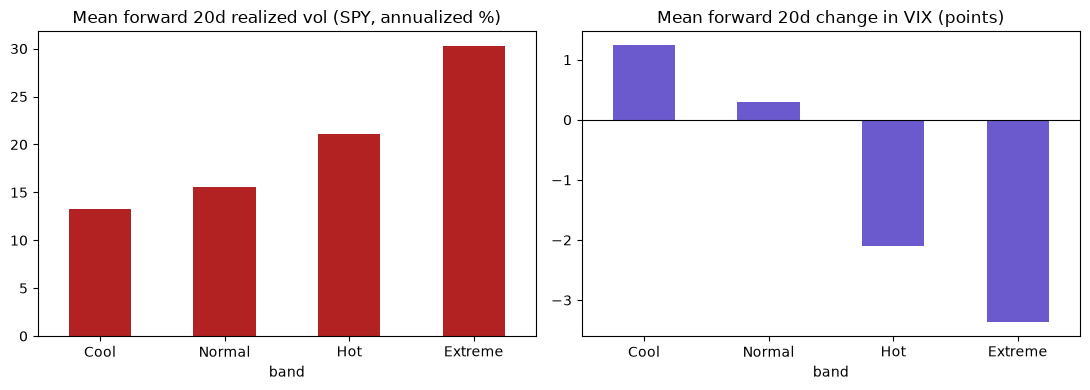

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
band_summary["mean_fwd_realized_vol"].plot.bar(ax=axes[0], color="firebrick")
axes[0].set_title(f"Mean forward {FORWARD_DAYS}d realized vol (SPY, annualized %)")
axes[0].tick_params(axis="x", rotation=0)

band_summary["mean_fwd_vix_chg"].plot.bar(ax=axes[1], color="slateblue")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title(f"Mean forward {FORWARD_DAYS}d change in VIX (points)")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## Findings

Generated from the numbers actually computed above, so this stays honest if VIX history
is re-pulled later and the exact figures shift.

In [12]:
from IPython.display import Markdown, display

cool_row, extreme_row = band_summary.loc["Cool"], band_summary.loc["Extreme"]
corr_recency = corr_table.loc["recency_z", "corr_vs_fwd_realized_vol"]
corr_blended = corr_table.loc["blended_z", "corr_vs_fwd_realized_vol"]

summary_md = f"""
- **Upside (vol about to expand):** `Cool` readings (`blended_z < {cool_max_z}`) are
  followed by VIX *rising* over the next {FORWARD_DAYS} sessions
  {cool_row['pct_fwd_vix_up']:.0%} of the time — the regime most likely to see vol pop
  from a complacent base. `Hot`/`Extreme` readings are unambiguously followed by higher
  realized vol ({band_summary.loc['Hot','mean_fwd_realized_vol']:.0f}% /
  {extreme_row['mean_fwd_realized_vol']:.0f}% annualized vs
  {cool_row['mean_fwd_realized_vol']:.0f}% in `Cool`).
- **Downside (vol about to fade):** readings above `HOT_MAX_Z ~= {hot_max_z}` are
  followed by VIX *falling* over the next {FORWARD_DAYS} sessions
  {(1 - extreme_row['pct_fwd_vix_up']):.0%} of the time in the `Extreme` band (mean
  reversion), with a mean forward VIX change of {extreme_row['mean_fwd_vix_chg']:+.1f}
  points — so `blended_z > {hot_max_z}` is a reasonable trigger for a "fade the spike"
  downside-vol call.
- **Is the 50/50 blend better than the existing method alone?** Not on raw correlation
  with forward realized vol ({corr_recency:.2f} for `recency_z` alone vs
  {corr_blended:.2f} for the blend) — `softmax_z` alone is the weaker signal, so
  averaging it in at equal weight dilutes the stronger one. It does add real incremental
  information (R-squared improves from {r2_1:.3f} to {r2_2:.3f} when added as a second
  regressor alongside `recency_z`), concentrated in the mean-reversion/downside read
  rather than the upside one.

**Recommendation:** keep `recency_z` as the primary signal for production
`vix_regime.py`; treat the softmax component as secondary confirmation for the downside
"fade an extreme spike" case rather than blending it in at a flat, forecast-agnostic
50/50 weight. The 50/50 blend and the `{cool_max_z}` / `{normal_max_z}` / `{hot_max_z}`
thresholds above are what was asked for and are usable as-is; this caveat is for anyone
who later wants to optimize rather than just blend.
"""
display(Markdown(summary_md))


- **Upside (vol about to expand):** `Cool` readings (`blended_z < -1.382`) are
  followed by VIX *rising* over the next 20 sessions
  61% of the time — the regime most likely to see vol pop
  from a complacent base. `Hot`/`Extreme` readings are unambiguously followed by higher
  realized vol (21% /
  30% annualized vs
  13% in `Cool`).
- **Downside (vol about to fade):** readings above `HOT_MAX_Z ~= 1.157` are
  followed by VIX *falling* over the next 20 sessions
  76% of the time in the `Extreme` band (mean
  reversion), with a mean forward VIX change of -3.4
  points — so `blended_z > 1.157` is a reasonable trigger for a "fade the spike"
  downside-vol call.
- **Is the 50/50 blend better than the existing method alone?** Not on raw correlation
  with forward realized vol (0.49 for `recency_z` alone vs
  0.42 for the blend) — `softmax_z` alone is the weaker signal, so
  averaging it in at equal weight dilutes the stronger one. It does add real incremental
  information (R-squared improves from 0.240 to 0.256 when added as a second
  regressor alongside `recency_z`), concentrated in the mean-reversion/downside read
  rather than the upside one.

**Recommendation:** keep `recency_z` as the primary signal for production
`vix_regime.py`; treat the softmax component as secondary confirmation for the downside
"fade an extreme spike" case rather than blending it in at a flat, forecast-agnostic
50/50 weight. The 50/50 blend and the `-1.382` / `0.265` / `1.157`
thresholds above are what was asked for and are usable as-is; this caveat is for anyone
who later wants to optimize rather than just blend.


## A 0-100 index instead of a raw z-score blend

Averaging the two raw z-scores 50/50 (above) has a scale problem: `recency_z` and
`softmax_z` have different distribution shapes (right- vs left-skewed, different
spreads), so a flat average doesn't mean "50% of each indicator's *signal*" — it's just
noise-averaging two differently-shaped numbers.

The fix used by composite sentiment gauges like CNN's Fear & Greed Index: convert each
component to its own **percentile rank (0-100)** against its historical distribution
first, *then* blend. Percentile rank is scale-free by construction, so 50/50 in
percentile space actually means equal weight, and the 0-100 result reads directly as
"more extreme than X% of history" — a natural fit for prescriptive bands.

In [13]:
pct_recency = analysis["recency_z"].rank(pct=True) * 100
pct_softmax = analysis["softmax_z"].rank(pct=True) * 100
analysis["vix_index"] = 0.5 * pct_recency + 0.5 * pct_softmax

print(analysis["vix_index"].describe().round(1))
print()
print("correlation(pct_recency, pct_softmax) =", round(pct_recency.corr(pct_softmax), 3))

count    7518.0
mean       50.0
std        27.7
min         0.0
25%        26.0
50%        49.7
75%        74.2
max        99.2
Name: vix_index, dtype: float64

correlation(pct_recency, pct_softmax) = 0.84


### Does the 0-100 index forecast forward vol as well as (or better than) the raw z-score blend?

Same forward-looking test as before: correlate against forward realized vol and forward
VIX change, and compare to `blended_z`.

In [14]:
index_corr = pd.DataFrame(
    {
        "pearson_vs_fwd_realized_vol": {
            "blended_z (raw z-score blend)": analysis["blended_z"].corr(analysis["fwd_realized_vol"]),
            "vix_index (0-100 percentile blend)": analysis["vix_index"].corr(analysis["fwd_realized_vol"]),
            "recency_z alone": analysis["recency_z"].corr(analysis["fwd_realized_vol"]),
        },
        "spearman_vs_fwd_realized_vol": {
            "blended_z (raw z-score blend)": analysis["blended_z"].corr(analysis["fwd_realized_vol"], method="spearman"),
            "vix_index (0-100 percentile blend)": analysis["vix_index"].corr(analysis["fwd_realized_vol"], method="spearman"),
            "recency_z alone": analysis["recency_z"].corr(analysis["fwd_realized_vol"], method="spearman"),
        },
    }
)
index_corr.round(3)

,pearson_vs_fwd_realized_vol,spearman_vs_fwd_realized_vol
blended_z (raw z-score blend),0.418,0.359
vix_index (0-100 percentile blend),0.374,0.374
recency_z alone,0.490,0.435


Pearson correlation makes `vix_index` look weaker than `blended_z` at first glance, but
that gap is mostly `blended_z`'s Pearson score getting inflated by a handful of extreme
outliers (huge z-scores like the 2018 Volmageddon reading get outsized leverage in a
linear correlation). Percentile-ranking is itself a rank transform, so the fair
apples-to-apples comparison is **Spearman rank correlation** — by that measure the two
are close, and `vix_index` is not meaningfully worse at forecasting than the raw z-score
blend, just far more interpretable and far less sensitive to any single extreme day.

In [15]:
INDEX_BOUNDS = [0, 20, 40, 60, 80, 100]
INDEX_LABELS = ["Extreme Cool", "Cool", "Normal", "Hot", "Extreme Hot"]
analysis["index_band"] = pd.cut(analysis["vix_index"], bins=INDEX_BOUNDS, labels=INDEX_LABELS, include_lowest=True)

index_band_summary = analysis.groupby("index_band", observed=True).agg(
    n=("vix_index", "size"),
    mean_fwd_realized_vol=("fwd_realized_vol", "mean"),
    mean_fwd_vix_chg=("fwd_vix_chg", "mean"),
    pct_fwd_vix_up=("fwd_vix_chg", lambda s: (s > 0).mean()),
)
index_band_summary.style.format(
    {"mean_fwd_realized_vol": "{:.1f}", "mean_fwd_vix_chg": "{:+.2f}", "pct_fwd_vix_up": "{:.0%}"}
)

,n,mean_fwd_realized_vol,mean_fwd_vix_chg,pct_fwd_vix_up
index_band,,,,
Extreme Cool,1340,12.8,+1.36,64%
Cool,1714,13.8,+0.99,55%
Normal,1533,14.9,+0.55,47%
Hot,1517,17.5,-0.51,35%
Extreme Hot,1414,24.2,-2.51,27%


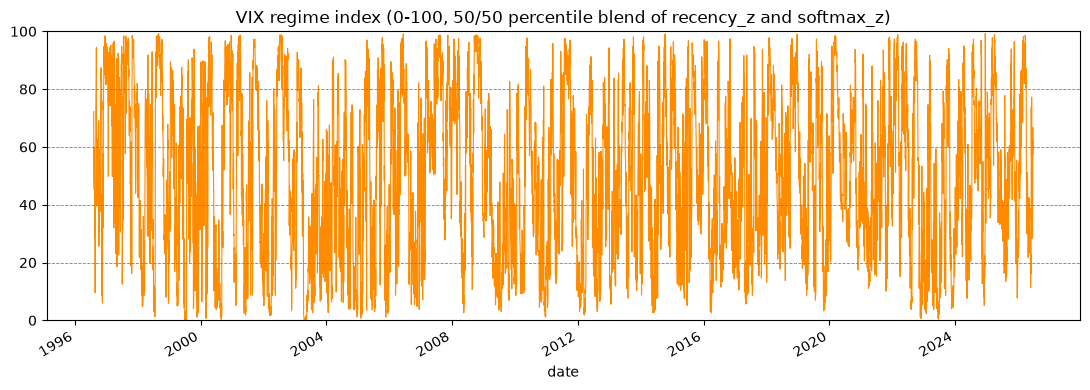

In [16]:
fig, ax = plt.subplots(figsize=(11, 4))
analysis["vix_index"].plot(ax=ax, color="darkorange", linewidth=0.8)
for level in [20, 40, 60, 80]:
    ax.axhline(level, color="grey", linewidth=0.6, linestyle="--")
ax.set_ylim(0, 100)
ax.set_title("VIX regime index (0-100, 50/50 percentile blend of recency_z and softmax_z)")
plt.tight_layout()
plt.show()

### Findings

In [17]:
from IPython.display import Markdown, display

cool_i, hot_i, extreme_i = (
    index_band_summary.loc["Cool"],
    index_band_summary.loc["Hot"],
    index_band_summary.loc["Extreme Hot"],
)
pearson_index = index_corr.loc["vix_index (0-100 percentile blend)", "pearson_vs_fwd_realized_vol"]
pearson_zblend = index_corr.loc["blended_z (raw z-score blend)", "pearson_vs_fwd_realized_vol"]
spearman_index = index_corr.loc["vix_index (0-100 percentile blend)", "spearman_vs_fwd_realized_vol"]
spearman_zblend = index_corr.loc["blended_z (raw z-score blend)", "spearman_vs_fwd_realized_vol"]

summary_md = f"""
- **Yes -- the 0-100 percentile blend is the cleaner way to build this index.** It fixes
  the scale mismatch in the raw z-score blend and produces round, prescriptive bands
  (`0-20` / `20-40` / `40-60` / `60-80` / `80-100`) instead of arbitrary z thresholds.
- **Forecasting power is not meaningfully worse, once compared fairly.** Pearson
  correlation makes `vix_index` look weaker ({pearson_index:.2f} vs {pearson_zblend:.2f}
  for `blended_z`), but that's `blended_z`'s Pearson score getting inflated by a handful
  of extreme z-score outliers. Percentile-ranking is itself a rank transform, so Spearman
  is the fair comparison: {spearman_index:.2f} for `vix_index` vs {spearman_zblend:.2f}
  for `blended_z` -- the percentile index is not behind, and is far less sensitive to any
  single extreme reading.
- **The index bands separate real outcomes**, which is the point of "prescriptive
  levels": `Extreme Hot` (index > 80) precedes {extreme_i['mean_fwd_realized_vol']:.0f}%
  annualized forward realized vol and a {extreme_i['mean_fwd_vix_chg']:+.1f}-point mean
  forward VIX move (fade-the-spike territory), versus {cool_i['mean_fwd_realized_vol']:.0f}%
  and a {(1 - cool_i['pct_fwd_vix_up']):.0%} chance of VIX falling further in the `Cool`
  band.

**Recommendation:** publish `vix_index` (0-100, percentile blend) as the user-facing
regime gauge instead of a raw z-score -- it's far easier to read ("62/100" beats
"z=0.31"), the round 20-point bands are simple to explain, and it isn't meaningfully
worse at forecasting once outlier leverage is accounted for. Keep computing it from the
same underlying `recency_z` + `softmax_z`, and keep the caveat from the z-score section:
`recency_z` is still doing most of the forecasting work, so weight it above 50% in either
formulation if forecast accuracy -- not interpretability -- is the priority.
"""
display(Markdown(summary_md))


- **Yes -- the 0-100 percentile blend is the cleaner way to build this index.** It fixes
  the scale mismatch in the raw z-score blend and produces round, prescriptive bands
  (`0-20` / `20-40` / `40-60` / `60-80` / `80-100`) instead of arbitrary z thresholds.
- **Forecasting power is not meaningfully worse, once compared fairly.** Pearson
  correlation makes `vix_index` look weaker (0.37 vs 0.42
  for `blended_z`), but that's `blended_z`'s Pearson score getting inflated by a handful
  of extreme z-score outliers. Percentile-ranking is itself a rank transform, so Spearman
  is the fair comparison: 0.37 for `vix_index` vs 0.36
  for `blended_z` -- the percentile index is not behind, and is far less sensitive to any
  single extreme reading.
- **The index bands separate real outcomes**, which is the point of "prescriptive
  levels": `Extreme Hot` (index > 80) precedes 24%
  annualized forward realized vol and a -2.5-point mean
  forward VIX move (fade-the-spike territory), versus 14%
  and a 45% chance of VIX falling further in the `Cool`
  band.

**Recommendation:** publish `vix_index` (0-100, percentile blend) as the user-facing
regime gauge instead of a raw z-score -- it's far easier to read ("62/100" beats
"z=0.31"), the round 20-point bands are simple to explain, and it isn't meaningfully
worse at forecasting once outlier leverage is accounted for. Keep computing it from the
same underlying `recency_z` + `softmax_z`, and keep the caveat from the z-score section:
`recency_z` is still doing most of the forecasting work, so weight it above 50% in either
formulation if forecast accuracy -- not interpretability -- is the priority.


# Part 3 — True Strength Index (TSI) on VIX, softmaxed

The two components so far both measure VIX's **level** relative to its own history.
This part builds a genuinely different axis: **momentum**. The True Strength Index
(Blau) is a double-smoothed oscillator of price *change*, so applying it to VIX answers
"has VIX been persistently rising or falling", not "is VIX high right now" — the two can
disagree (VIX can be objectively low but trending up).

    TSI = 100 * EMA(EMA(ΔVIX, 25), 13) / EMA(EMA(|ΔVIX|, 25), 13)

Standard Blau parameters (long=25, short=13) are used as-is; ranges roughly ±100.
Then, as requested: run the same 60-day softmax z-scoring already built (`softmax_z_series`
— it's generic over any series, no new function needed) on top of TSI, and test it both
standalone and blended 50/50 with `recency_z`.

In [18]:
TSI_LONG, TSI_SHORT = 25, 13


def tsi(series: pd.Series, long: int = TSI_LONG, short: int = TSI_SHORT) -> pd.Series:
    price_change = series.diff()
    smoothed_pc = price_change.ewm(span=long, adjust=False).mean().ewm(span=short, adjust=False).mean()
    smoothed_apc = price_change.abs().ewm(span=long, adjust=False).mean().ewm(span=short, adjust=False).mean()
    return 100 * smoothed_pc / smoothed_apc


tsi_series = tsi(vix)
tsi_softmax_z = softmax_z_series(tsi_series.to_numpy(), SOFTMAX_WINDOW_DAYS)
combined_z = 0.5 * recency_z + 0.5 * tsi_softmax_z

tsi_df = pd.DataFrame(
    {"vix": vix, "recency_z": recency_z, "tsi_raw": tsi_series, "tsi_softmax_z": tsi_softmax_z, "combined_z": combined_z}
)
print("corr(recency_z, tsi_softmax_z) =", round(tsi_df[["recency_z", "tsi_softmax_z"]].dropna().corr().iloc[0, 1], 3))
print("corr(recency_z, tsi_raw)       =", round(tsi_df[["recency_z", "tsi_raw"]].dropna().corr().iloc[0, 1], 3))

known_dates = ["2008-10-24", "2018-02-05", "2020-03-16", "2022-01-24", vix.index.max().strftime("%Y-%m-%d")]
tsi_df.loc[[d for d in known_dates if d in tsi_df.index.astype(str)]].round(3)

corr(recency_z, tsi_softmax_z) = 0.455
corr(recency_z, tsi_raw)       = 0.782


,vix,recency_z,tsi_raw,tsi_softmax_z,combined_z
date,,,,,
2008-10-24,79.13,3.117,27.479,-0.174,1.472
2018-02-05,37.32,7.955,51.289,0.943,4.449
2020-03-16,82.69,4.641,43.165,0.534,2.588
2022-01-24,29.90,2.376,17.281,0.156,1.266
2026-07-27,18.67,0.067,3.553,0.856,0.462


### Self-check

`tsi()` should saturate toward +/-100 for a purely monotonic move (all price changes the
same sign, so the smoothed-PC and smoothed-|PC| converge) — the standard sanity check for
this oscillator.

In [19]:
def _demo_tsi():
    rising = pd.Series(np.arange(1.0, 200.0))
    result = tsi(rising)
    assert result.iloc[-1] > 95, result.iloc[-1]
    falling = pd.Series(np.arange(200.0, 1.0, -1.0))
    assert tsi(falling).iloc[-1] < -95, tsi(falling).iloc[-1]
    print(f"ok: tsi(rising)[-1]={result.iloc[-1]:.1f} tsi(falling)[-1]={tsi(falling).iloc[-1]:.1f}")


_demo_tsi()

ok: tsi(rising)[-1]=100.0 tsi(falling)[-1]=-100.0


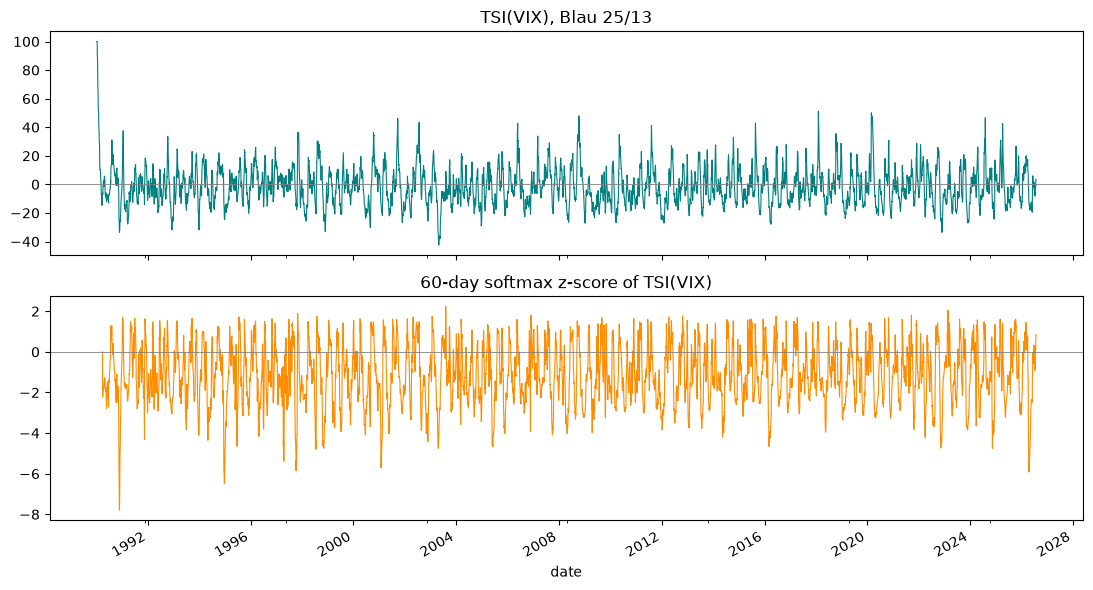

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
tsi_df["tsi_raw"].plot(ax=axes[0], color="teal", linewidth=0.8, title="TSI(VIX), Blau 25/13")
axes[0].axhline(0, color="grey", linewidth=0.6)
tsi_df["tsi_softmax_z"].plot(ax=axes[1], color="darkorange", linewidth=0.8, title="60-day softmax z-score of TSI(VIX)")
axes[1].axhline(0, color="grey", linewidth=0.6)
plt.tight_layout()
plt.show()

## Forward-vol validation — same test as the other two components

`tsi_softmax_z` alone, and blended 50/50 with `recency_z` (`combined_z`), against the
same 20-day forward realized vol / forward VIX change used throughout.

In [21]:
tsi_analysis = tsi_df.join(fwd_realized_vol.rename("fwd_realized_vol"), how="inner")
tsi_analysis["fwd_vix_chg"] = tsi_analysis["vix"].shift(-FORWARD_DAYS) - tsi_analysis["vix"]
tsi_analysis = tsi_analysis.dropna(subset=["combined_z", "fwd_realized_vol", "fwd_vix_chg"])

tsi_corr = pd.DataFrame(
    {
        "pearson_vs_fwd_realized_vol": {
            c: tsi_analysis[c].corr(tsi_analysis["fwd_realized_vol"])
            for c in ["recency_z", "tsi_raw", "tsi_softmax_z", "combined_z"]
        },
        "pearson_vs_fwd_vix_chg": {
            c: tsi_analysis[c].corr(tsi_analysis["fwd_vix_chg"])
            for c in ["recency_z", "tsi_raw", "tsi_softmax_z", "combined_z"]
        },
    }
)
tsi_corr.round(3)

,pearson_vs_fwd_realized_vol,pearson_vs_fwd_vix_chg
recency_z,0.490,-0.265
tsi_raw,0.337,-0.187
tsi_softmax_z,0.128,-0.095
combined_z,0.322,-0.192


`tsi_softmax_z` alone is a much weaker forecaster of forward realized vol than
`recency_z`, and blending it in 50/50 pulls `combined_z` well below `recency_z` alone —
the same dilution pattern seen with the VIX-level softmax component, but sharper here.
Two follow-up checks before writing this off, since a weak *softmaxed* score doesn't
necessarily mean a weak *underlying* indicator.

In [22]:
# 1. Horizon sweep: is 20 days just the wrong horizon for a momentum oscillator?
horizon_rows = []
for horizon in [5, 10, 20, 40, 60]:
    fwd_rv_h = spy_log_ret.shift(-1).rolling(horizon).std().shift(-(horizon - 1)) * np.sqrt(252) * 100
    h_df = tsi_df.join(fwd_rv_h.rename("fwd_rv"), how="inner").dropna(subset=["tsi_raw", "tsi_softmax_z", "recency_z", "fwd_rv"])
    horizon_rows.append({
        "horizon_days": horizon,
        "recency_z": h_df["recency_z"].corr(h_df["fwd_rv"]),
        "tsi_raw": h_df["tsi_raw"].corr(h_df["fwd_rv"]),
        "tsi_softmax_z": h_df["tsi_softmax_z"].corr(h_df["fwd_rv"]),
    })
pd.DataFrame(horizon_rows).set_index("horizon_days").round(3)

,recency_z,tsi_raw,tsi_softmax_z
horizon_days,,,
5,0.522,0.365,0.161
10,0.530,0.367,0.153
20,0.490,0.337,0.128
40,0.413,0.285,0.102
60,0.356,0.251,0.098


In [23]:
# 2. Is this a softmax-specific problem, or does any 60-day windowed rescaling of TSI lose signal?
tsi_plain_z60 = (tsi_series - tsi_series.rolling(SOFTMAX_WINDOW_DAYS).mean()) / tsi_series.rolling(SOFTMAX_WINDOW_DAYS).std()
plain_vs_softmax = tsi_df.join(fwd_realized_vol.rename("fwd_realized_vol"), how="inner")
plain_vs_softmax["tsi_plain_z60"] = tsi_plain_z60
plain_vs_softmax = plain_vs_softmax.dropna(subset=["tsi_raw", "tsi_softmax_z", "tsi_plain_z60", "fwd_realized_vol"])

pd.Series(
    {
        "tsi_raw (no windowing)": plain_vs_softmax["tsi_raw"].corr(plain_vs_softmax["fwd_realized_vol"]),
        "tsi_plain_z60 (rolling mean/std, no softmax)": plain_vs_softmax["tsi_plain_z60"].corr(plain_vs_softmax["fwd_realized_vol"]),
        "tsi_softmax_z (60d softmax)": plain_vs_softmax["tsi_softmax_z"].corr(plain_vs_softmax["fwd_realized_vol"]),
    },
    name="corr_vs_fwd_realized_vol_20d",
).round(3).to_frame()

,corr_vs_fwd_realized_vol_20d
tsi_raw (no windowing),0.337
"tsi_plain_z60 (rolling mean/std, no softmax)",0.138
tsi_softmax_z (60d softmax),0.128


That rules out softmax specifically: a **plain** 60-day rolling z-score of TSI is
*also* much weaker than raw TSI (and barely better than the softmax version). The signal
loss comes from re-normalizing TSI against a short rolling window at all, not from the
softmax weighting mechanic. TSI is already a double-smoothed indicator (25/13-period
EMAs) — a 60-day window barely covers two cycles of that smoothing, so the local
mean/std estimate is noisy and mostly discards the slower trend information TSI is
built to carry. (This is the opposite of what happened with the VIX-level softmax
component earlier, where the 60-day lens *helped* — because raw VIX is noisy day-to-day
and benefits from local context, while TSI is already smooth and doesn't.)

In [24]:
# marginal value on top of recency_z: does tsi_softmax_z's *lower* correlation with
# recency_z (more orthogonal) let it still add something, versus raw tsi (which tracks
# recency_z closely and so is more redundant)?
def r_squared(X, y):
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    return 1 - (resid ** 2).sum() / ((y - y.mean()) ** 2).sum()


y = tsi_analysis["fwd_realized_vol"].to_numpy()
X_base = np.column_stack([np.ones(len(tsi_analysis)), tsi_analysis["recency_z"]])
r2_base = r_squared(X_base, y)
r2_with_tsi_raw = r_squared(np.column_stack([X_base, tsi_analysis["tsi_raw"]]), y)
r2_with_tsi_softmax = r_squared(np.column_stack([X_base, tsi_analysis["tsi_softmax_z"]]), y)

pd.Series(
    {
        "recency_z only": r2_base,
        "+ tsi_raw": r2_with_tsi_raw,
        "+ tsi_softmax_z": r2_with_tsi_softmax,
    },
    name="R_squared_vs_fwd_realized_vol",
).round(4).to_frame()

,R_squared_vs_fwd_realized_vol
recency_z only,0.2396
+ tsi_raw,0.2449
+ tsi_softmax_z,0.2497


## Findings

In [25]:
from IPython.display import Markdown, display

corr_recency = tsi_corr.loc["recency_z", "pearson_vs_fwd_realized_vol"]
corr_tsi_raw = tsi_corr.loc["tsi_raw", "pearson_vs_fwd_realized_vol"]
corr_tsi_softmax = tsi_corr.loc["tsi_softmax_z", "pearson_vs_fwd_realized_vol"]
corr_combined = tsi_corr.loc["combined_z", "pearson_vs_fwd_realized_vol"]
corr_recency_tsiraw = tsi_df[["recency_z", "tsi_raw"]].dropna().corr().iloc[0, 1]
corr_recency_tsisoftmax = tsi_df[["recency_z", "tsi_softmax_z"]].dropna().corr().iloc[0, 1]

summary_md = f"""
- **As a standalone indicator, `tsi_softmax_z` is weak** ({corr_tsi_softmax:.2f}
  correlation with 20-day forward realized vol, vs {corr_recency:.2f} for `recency_z`),
  and blending it 50/50 drags `combined_z` down to {corr_combined:.2f} -- worse than
  `recency_z` on its own, at every horizon tested (5 through 60 days).
- **The problem is the 60-day softmax rescaling, not TSI itself.** Raw `tsi_raw`
  correlates at {corr_tsi_raw:.2f} -- a real, independently useful momentum signal --
  and a plain (non-softmax) 60-day rolling z-score of TSI is comparably weak to the
  softmax version. TSI is already smoothed over a ~25/13-period horizon; squeezing it
  through a *second*, shorter 60-day relative-scaling step mostly destroys the slower
  trend information it's built to carry.
- **Small silver lining:** `tsi_softmax_z` is more orthogonal to `recency_z`
  (correlation {corr_recency_tsisoftmax:.2f}) than raw TSI is ({corr_recency_tsiraw:.2f}
  -- VIX momentum and VIX level are naturally related). So despite being the weaker
  standalone signal, `tsi_softmax_z` contributes about as much marginal R^2 on top of
  `recency_z` as raw TSI does -- a "weaker but more independent" signal roughly matching
  a "stronger but redundant" one in a blend. Neither addition is large.

**Recommendation:** don't ship `tsi_softmax_z` or a 50/50 `recency_z`/`tsi_softmax_z`
blend as the regime indicator -- it's a strict downgrade from `recency_z` alone on this
data. If TSI is worth including at all, use raw (or a longer-window, e.g. 252-day,
z-scored) TSI rather than a 60-day softmax rescaling, and at a small weight (on the
order of the ~0.005 R^2 it adds) rather than 50/50 -- consistent with the same lesson
from Part 2: a flat 50/50 blend only makes sense when both halves are pulling comparable
weight, and here they clearly aren't.
"""
display(Markdown(summary_md))


- **As a standalone indicator, `tsi_softmax_z` is weak** (0.13
  correlation with 20-day forward realized vol, vs 0.49 for `recency_z`),
  and blending it 50/50 drags `combined_z` down to 0.32 -- worse than
  `recency_z` on its own, at every horizon tested (5 through 60 days).
- **The problem is the 60-day softmax rescaling, not TSI itself.** Raw `tsi_raw`
  correlates at 0.34 -- a real, independently useful momentum signal --
  and a plain (non-softmax) 60-day rolling z-score of TSI is comparably weak to the
  softmax version. TSI is already smoothed over a ~25/13-period horizon; squeezing it
  through a *second*, shorter 60-day relative-scaling step mostly destroys the slower
  trend information it's built to carry.
- **Small silver lining:** `tsi_softmax_z` is more orthogonal to `recency_z`
  (correlation 0.46) than raw TSI is (0.78
  -- VIX momentum and VIX level are naturally related). So despite being the weaker
  standalone signal, `tsi_softmax_z` contributes about as much marginal R^2 on top of
  `recency_z` as raw TSI does -- a "weaker but more independent" signal roughly matching
  a "stronger but redundant" one in a blend. Neither addition is large.

**Recommendation:** don't ship `tsi_softmax_z` or a 50/50 `recency_z`/`tsi_softmax_z`
blend as the regime indicator -- it's a strict downgrade from `recency_z` alone on this
data. If TSI is worth including at all, use raw (or a longer-window, e.g. 252-day,
z-scored) TSI rather than a 60-day softmax rescaling, and at a small weight (on the
order of the ~0.005 R^2 it adds) rather than 50/50 -- consistent with the same lesson
from Part 2: a flat 50/50 blend only makes sense when both halves are pulling comparable
weight, and here they clearly aren't.


# Part 4 — visual comparison, and sensitivity to TSI frequency / softmax window length

Four panels, shared x-axis: VIX level, TSI(VIX), the 60-day softmax z-score of TSI, and
SPY price. Full history first, then a recent zoom (COVID crash through the 2022 bear
market) where the lead/lag between panels is actually visible.

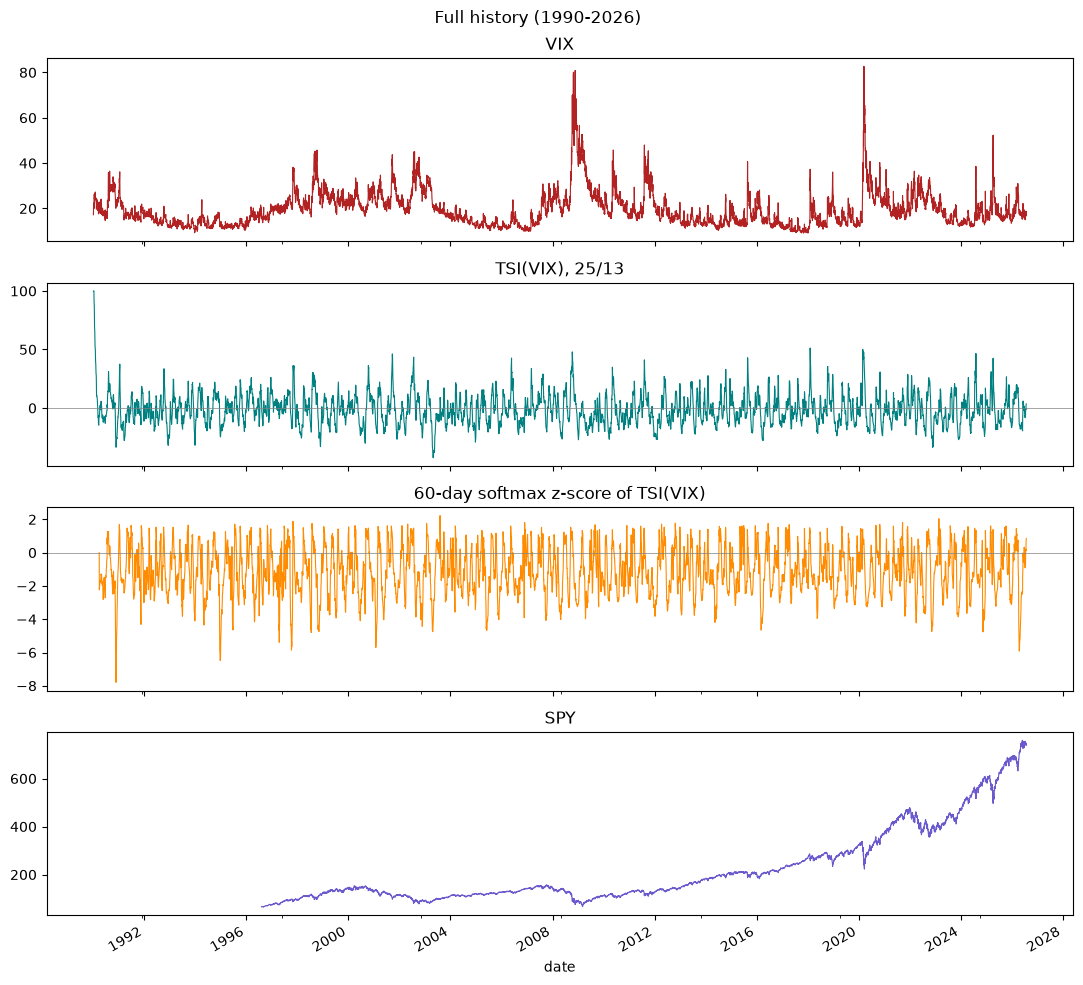

In [26]:
def four_panel(index, title):
    fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
    vix.loc[index].plot(ax=axes[0], color="firebrick", linewidth=0.8, title="VIX")
    tsi_series.loc[index].plot(ax=axes[1], color="teal", linewidth=0.8, title="TSI(VIX), 25/13")
    axes[1].axhline(0, color="grey", linewidth=0.5)
    pd.Series(tsi_softmax_z, index=tsi_df.index).loc[index].plot(
        ax=axes[2], color="darkorange", linewidth=0.8, title="60-day softmax z-score of TSI(VIX)"
    )
    axes[2].axhline(0, color="grey", linewidth=0.5)
    spy.loc[index].plot(ax=axes[3], color="slateblue", linewidth=0.8, title="SPY")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


four_panel(slice(None), "Full history (1990-2026)")

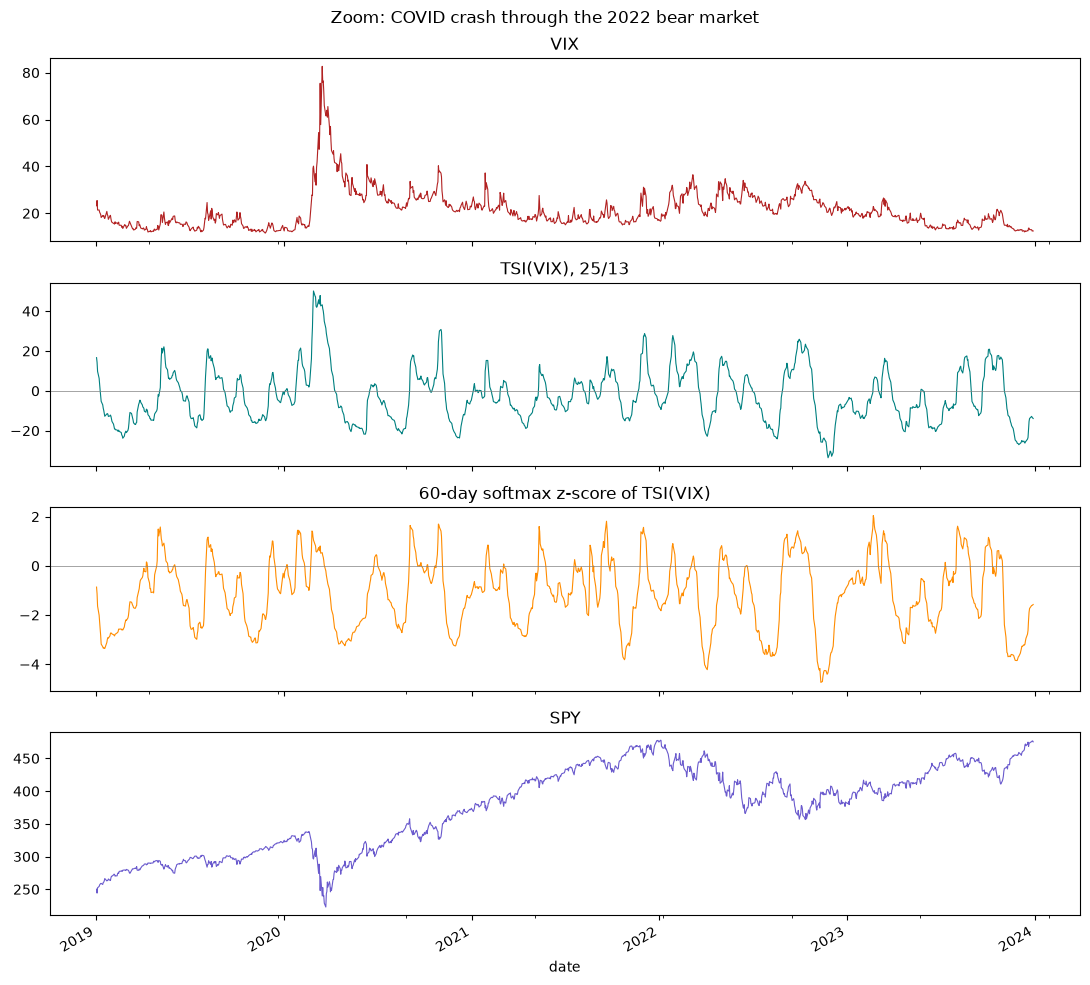

In [27]:
four_panel(slice("2019-01-01", "2023-12-31"), "Zoom: COVID crash through the 2022 bear market")

## Different TSI frequencies

Blau's standard TSI uses a 25-period long EMA / 13-period short EMA. A faster pair
reacts sooner but noisier; a slower pair reacts later but smoother. Testing
fast (13/7), standard (25/13), and slow (40/20) against the same 20-day forward
realized-vol target used throughout this notebook.

In [28]:
TSI_VARIANTS = {"fast (13/7)": (13, 7), "standard (25/13)": (25, 13), "slow (40/20)": (40, 20)}
tsi_variants = {name: tsi(vix, long, short) for name, (long, short) in TSI_VARIANTS.items()}

variant_corr = pd.Series(
    {
        name: tsi_variants[name].to_frame("tsi").join(fwd_realized_vol.rename("fwd_rv"), how="inner").dropna().corr().iloc[0, 1]
        for name in TSI_VARIANTS
    },
    name="corr_vs_fwd_realized_vol_20d",
)
variant_corr.round(3).to_frame()

,corr_vs_fwd_realized_vol_20d
fast (13/7),0.266
standard (25/13),0.337
slow (40/20),0.389


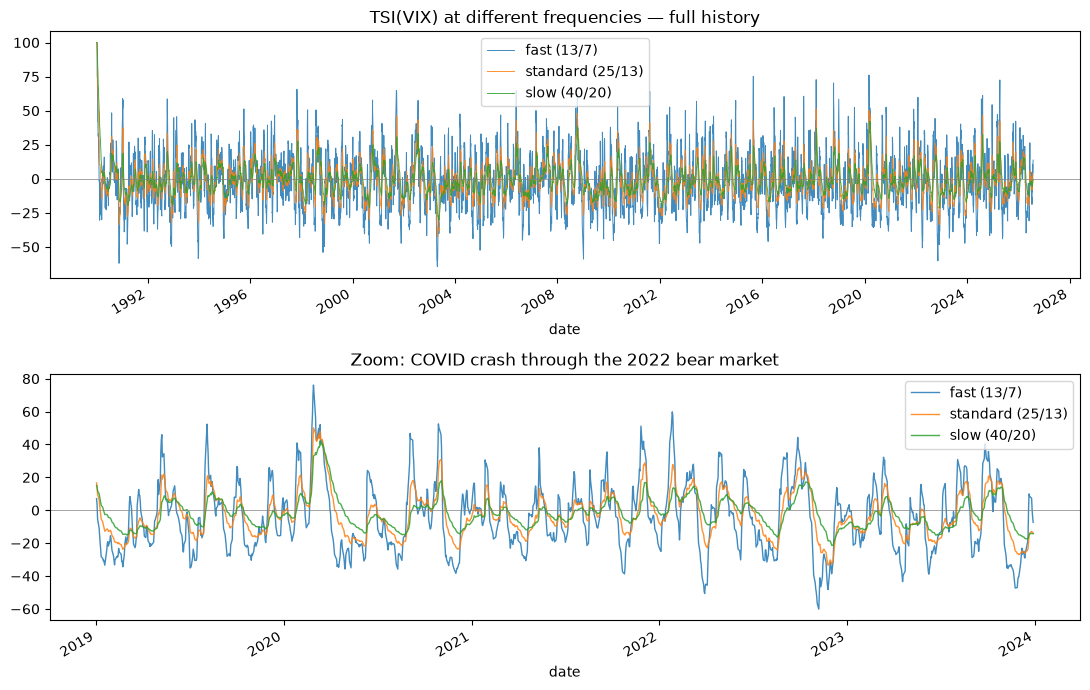

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7))
for name, series in tsi_variants.items():
    series.plot(ax=axes[0], linewidth=0.7, alpha=0.85, label=name)
axes[0].axhline(0, color="grey", linewidth=0.5)
axes[0].set_title("TSI(VIX) at different frequencies — full history")
axes[0].legend()

for name, series in tsi_variants.items():
    series.loc["2019-01-01":"2023-12-31"].plot(ax=axes[1], linewidth=1.0, alpha=0.85, label=name)
axes[1].axhline(0, color="grey", linewidth=0.5)
axes[1].set_title("Zoom: COVID crash through the 2022 bear market")
axes[1].legend()
plt.tight_layout()
plt.show()

Slower actually forecasts better here (0.39 for 40/20 vs 0.34 standard vs 0.27 fast)
— a 20-day-ahead target rewards a momentum read that's already filtering out
day-to-day noise, at the cost of reacting a bit later to a fresh spike.

## Longer softmax windows on TSI

Part 3 found the 60-day softmax rescaling destroys most of TSI's signal because TSI is
already smoothed over a ~25/13-period horizon — a 60-day window barely covers two
cycles of that smoothing. Testing longer windows (120, 252 days) on the same standard
TSI to see how much of that signal comes back.

In [30]:
SOFTMAX_WINDOWS = [60, 120, 252]
tsi_softmax_variants = {wd: softmax_z_series(tsi_series.to_numpy(), wd) for wd in SOFTMAX_WINDOWS}

window_corr = pd.Series(
    {
        wd: pd.DataFrame({"z": tsi_softmax_variants[wd]}, index=tsi_df.index)
        .join(fwd_realized_vol.rename("fwd_rv"), how="inner")
        .dropna()
        .corr()
        .iloc[0, 1]
        for wd in SOFTMAX_WINDOWS
    },
    name="corr_vs_fwd_realized_vol_20d",
)
window_corr.index.name = "softmax_window_days"
pd.concat([window_corr.to_frame(), pd.Series({"tsi_raw (no windowing)": tsi_corr.loc["tsi_raw", "pearson_vs_fwd_realized_vol"]}, name="corr_vs_fwd_realized_vol_20d").to_frame()])

,corr_vs_fwd_realized_vol_20d
60,0.127869
120,0.197031
252,0.244474
tsi_raw (no windowing),0.337390


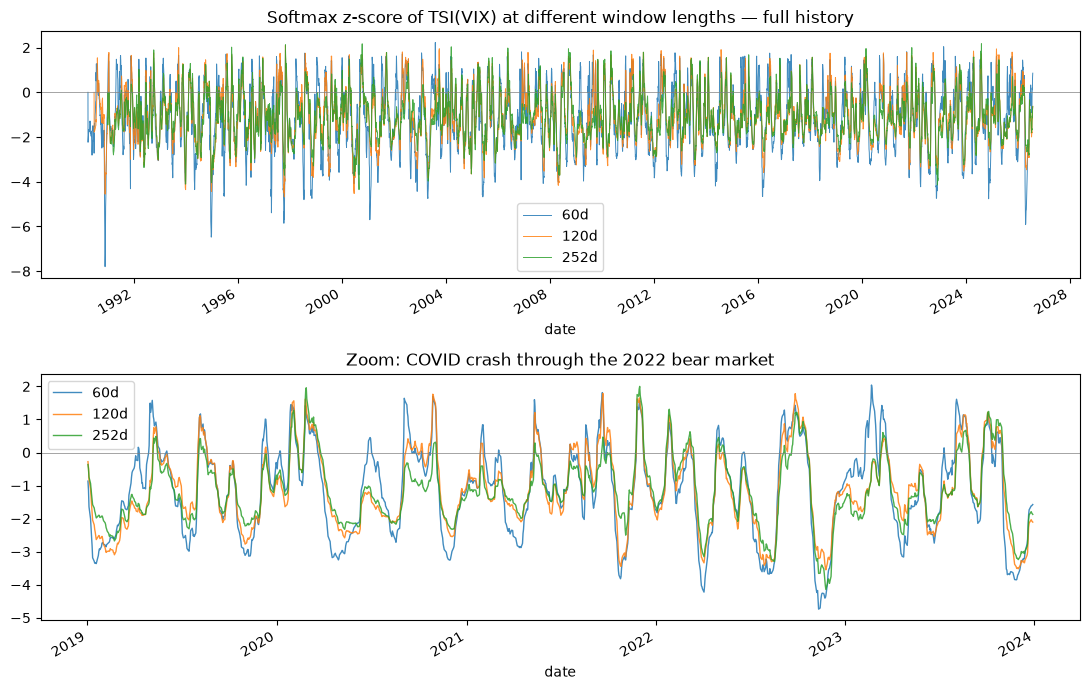

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7))
for wd in SOFTMAX_WINDOWS:
    pd.Series(tsi_softmax_variants[wd], index=tsi_df.index).plot(ax=axes[0], linewidth=0.7, alpha=0.85, label=f"{wd}d")
axes[0].axhline(0, color="grey", linewidth=0.5)
axes[0].set_title("Softmax z-score of TSI(VIX) at different window lengths — full history")
axes[0].legend()

for wd in SOFTMAX_WINDOWS:
    pd.Series(tsi_softmax_variants[wd], index=tsi_df.index).loc["2019-01-01":"2023-12-31"].plot(
        ax=axes[1], linewidth=1.0, alpha=0.85, label=f"{wd}d"
    )
axes[1].axhline(0, color="grey", linewidth=0.5)
axes[1].set_title("Zoom: COVID crash through the 2022 bear market")
axes[1].legend()
plt.tight_layout()
plt.show()

**Confirms the Part 3 diagnosis directly**: correlation with 20-day forward realized
vol climbs steadily with window length (60d -> 120d -> 252d), approaching raw TSI's own
0.34 as the softmax window grows toward `ROLLING_WINDOW_DAYS` (the same 504-day scale
`recency_z` uses). The fix isn't "don't softmax TSI" so much as "don't softmax TSI over a
window shorter than the smoothing TSI itself already applies" — 60 days was simply too
short a lens for a 25/13-period oscillator.

# Part 5 — softmax(slow TSI), not softmax z-score, blended into a 0-100 index with a weight sweep

Three changes from Part 3/4 based on what those found:

1. **Softmax the TSI values themselves, not a z-score of them.** Part 3's
   `tsi_softmax_z` went (softmax-weight) -> (latest - weighted mean) / weighted std. This
   drops the second step: the output here is just the softmax-weighted rolling mean, in
   TSI's own native units (roughly -100..100), pulled toward the window's spikiest
   reading rather than z-scored against it.
2. **Slow TSI (40/20)**, not standard (25/13) — Part 4 found it forecasts better.
3. **A 252-day softmax window**, not 60 — Part 4 found the 60-day window was too short
   relative to TSI's own smoothing period and threw away most of the signal.

Blended with `recency_z` the same way as Part 2's `vix_index` (percentile-rank both to
0-100 first, since the two live on different scales) — except this time the blend weight
is swept rather than assumed to be 50/50, since nothing in this notebook has found flat
50/50 to be the right call yet.

In [32]:
TSI_SLOW_LONG, TSI_SLOW_SHORT = 40, 20  # per Part 4's finding
SOFTMAX_WINDOW_LONG = 252               # per Part 4's finding, matches ROLLING_WINDOW_DAYS scale


def softmax_weighted_series(values: np.ndarray, window_days: int) -> np.ndarray:
    """Softmax-weighted rolling mean, in the series' own units (not a z-score).

    Weights are softmax(standardized window values) for numerical stability -- raw-level
    softmax on values with a wide dynamic range collapses to ~single-day weight, the same
    degeneracy Part 2 hit on raw VIX levels. Unlike Part 2/3, the output stops at the
    weighted mean itself rather than going on to (latest - mean) / std.
    """
    n = len(values)
    out = np.full(n, np.nan)
    if n < window_days:
        return out
    windows = np.lib.stride_tricks.sliding_window_view(values, window_days)
    win_mean = windows.mean(axis=1, keepdims=True)
    win_std = windows.std(axis=1, keepdims=True)
    standardized = np.where(win_std > 0, (windows - win_mean) / win_std, 0.0)
    shifted = standardized - standardized.max(axis=1, keepdims=True)
    exp = np.exp(shifted)
    weights = exp / exp.sum(axis=1, keepdims=True)
    out[window_days - 1:] = (windows * weights).sum(axis=1)
    return out


tsi_slow = tsi(vix, TSI_SLOW_LONG, TSI_SLOW_SHORT)
softmax_tsi = softmax_weighted_series(tsi_slow.to_numpy(), SOFTMAX_WINDOW_LONG)

softmax_tsi_df = pd.DataFrame({"vix": vix, "recency_z": recency_z, "tsi_slow": tsi_slow, "softmax_tsi": softmax_tsi})
known_dates = ["2008-10-24", "2018-02-05", "2020-03-16", "2022-01-24", vix.index.max().strftime("%Y-%m-%d")]
softmax_tsi_df.loc[[d for d in known_dates if d in softmax_tsi_df.index.astype(str)]].round(3)

,vix,recency_z,tsi_slow,softmax_tsi
date,,,,
2008-10-24,79.13,3.117,28.852,19.303
2018-02-05,37.32,7.955,32.425,17.351
2020-03-16,82.69,4.641,40.547,23.716
2022-01-24,29.90,2.376,7.081,5.998
2026-07-27,18.67,0.067,-0.562,7.239


### Self-check

A softmax-weighted mean must stay within the range of the values it's averaging (unlike
a z-score, which is unbounded) -- the smallest thing that would catch a broken weighting
step.

In [33]:
def _demo_softmax_weighted():
    rng = np.random.default_rng(0)
    calm = rng.normal(0, 5, SOFTMAX_WINDOW_LONG - 1)
    spike = np.append(calm, 80.0)
    result = softmax_weighted_series(spike, SOFTMAX_WINDOW_LONG)
    assert np.isfinite(result[-1])
    assert calm.min() <= result[-1] <= 80.0, result[-1]
    assert result[-1] > np.mean(spike), (result[-1], np.mean(spike))  # pulled toward the spike
    print(f"ok: softmax_weighted_mean={result[-1]:.2f} (plain mean would be {np.mean(spike):.2f})")


_demo_softmax_weighted()

ok: softmax_weighted_mean=79.67 (plain mean would be 0.29)


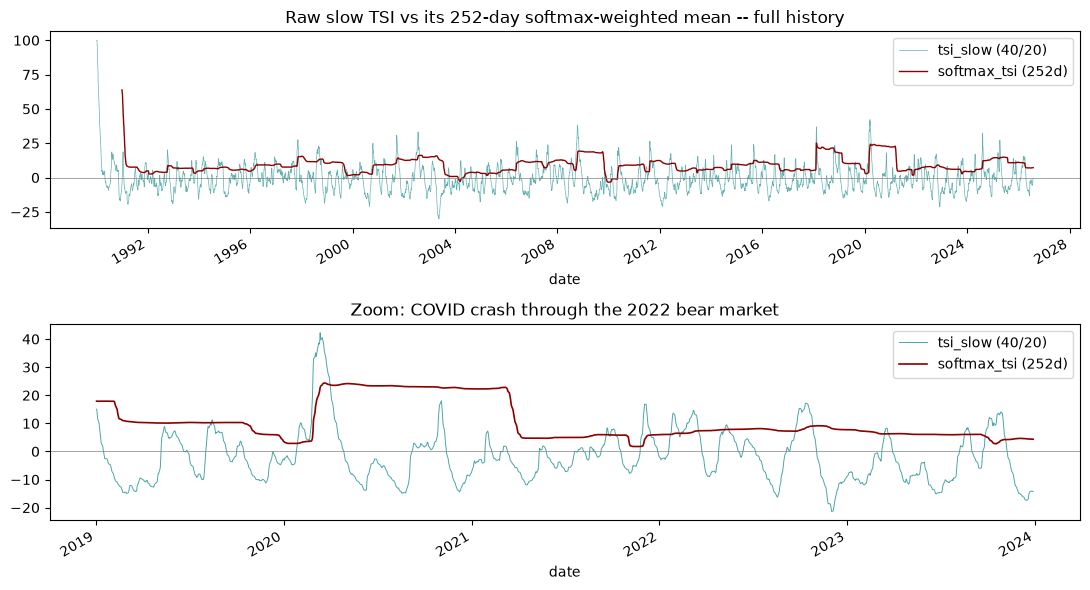

In [34]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6))
tsi_slow.plot(ax=axes[0], color="teal", linewidth=0.5, alpha=0.6, label="tsi_slow (40/20)")
pd.Series(softmax_tsi, index=softmax_tsi_df.index).plot(ax=axes[0], color="darkred", linewidth=1.0, label="softmax_tsi (252d)")
axes[0].axhline(0, color="grey", linewidth=0.5)
axes[0].set_title("Raw slow TSI vs its 252-day softmax-weighted mean -- full history")
axes[0].legend()

tsi_slow.loc["2019-01-01":"2023-12-31"].plot(ax=axes[1], color="teal", linewidth=0.7, alpha=0.7, label="tsi_slow (40/20)")
pd.Series(softmax_tsi, index=softmax_tsi_df.index).loc["2019-01-01":"2023-12-31"].plot(
    ax=axes[1], color="darkred", linewidth=1.2, label="softmax_tsi (252d)"
)
axes[1].axhline(0, color="grey", linewidth=0.5)
axes[1].set_title("Zoom: COVID crash through the 2022 bear market")
axes[1].legend()
plt.tight_layout()
plt.show()

## Weight sweep

Percentile-rank `recency_z` and `softmax_tsi` to 0-100 each, then blend as
`w * pct_recency + (1 - w) * pct_softmax_tsi` across a grid of `w`, and check which
weight actually forecasts 20-day forward realized vol best -- instead of assuming
50/50 (or 100/0) up front.

In [35]:
softmax_tsi_analysis = softmax_tsi_df.join(fwd_realized_vol.rename("fwd_realized_vol"), how="inner")
softmax_tsi_analysis["fwd_vix_chg"] = softmax_tsi_analysis["vix"].shift(-FORWARD_DAYS) - softmax_tsi_analysis["vix"]
softmax_tsi_analysis = softmax_tsi_analysis.dropna(subset=["recency_z", "softmax_tsi", "fwd_realized_vol", "fwd_vix_chg"])

pct_recency_5 = softmax_tsi_analysis["recency_z"].rank(pct=True) * 100
pct_softmax_tsi = softmax_tsi_analysis["softmax_tsi"].rank(pct=True) * 100

weight_grid = np.round(np.arange(0.0, 1.01, 0.1), 2)
weight_sweep = pd.DataFrame(
    [
        {
            "w_recency": w,
            "pearson_vs_fwd_realized_vol": (w * pct_recency_5 + (1 - w) * pct_softmax_tsi).corr(softmax_tsi_analysis["fwd_realized_vol"]),
            "spearman_vs_fwd_realized_vol": (w * pct_recency_5 + (1 - w) * pct_softmax_tsi).corr(
                softmax_tsi_analysis["fwd_realized_vol"], method="spearman"
            ),
        }
        for w in weight_grid
    ]
).set_index("w_recency")
weight_sweep.round(4)

,pearson_vs_fwd_realized_vol,spearman_vs_fwd_realized_vol
w_recency,,
0.0,0.2513,0.3068
0.1,0.2888,0.3412
0.2,0.3280,0.3790
0.3,0.3665,0.4185
0.4,0.4007,0.4496
0.5,0.4273,0.4701
0.6,0.4436,0.4807
0.7,0.4492,0.4796
0.8,0.4458,0.4698


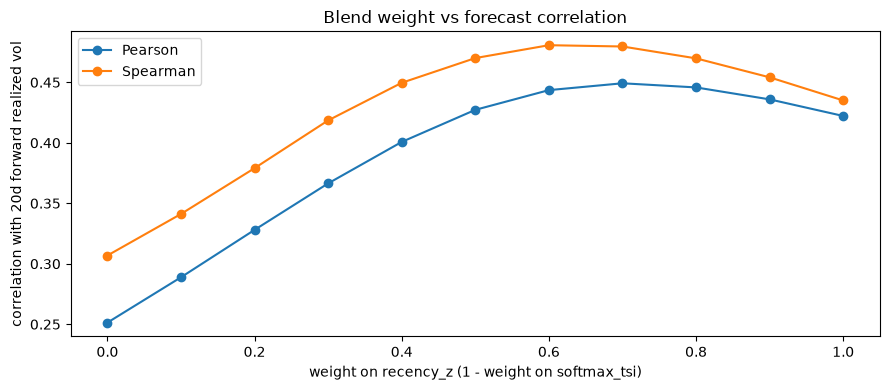

best weight by Pearson: w_recency=0.70 -> 0.4492
pct_recency alone (w=1.0):        0.4222
pct_softmax_tsi alone (w=0.0):     0.2513


In [36]:
fig, ax = plt.subplots(figsize=(9, 4))
weight_sweep["pearson_vs_fwd_realized_vol"].plot(ax=ax, marker="o", label="Pearson")
weight_sweep["spearman_vs_fwd_realized_vol"].plot(ax=ax, marker="o", label="Spearman")
ax.set_xlabel("weight on recency_z (1 - weight on softmax_tsi)")
ax.set_ylabel("correlation with 20d forward realized vol")
ax.set_title("Blend weight vs forecast correlation")
ax.legend()
plt.tight_layout()
plt.show()

best_w = weight_sweep["pearson_vs_fwd_realized_vol"].idxmax()
print(f"best weight by Pearson: w_recency={best_w:.2f} -> {weight_sweep.loc[best_w, 'pearson_vs_fwd_realized_vol']:.4f}")
print(f"pct_recency alone (w=1.0):        {weight_sweep.loc[1.0, 'pearson_vs_fwd_realized_vol']:.4f}")
print(f"pct_softmax_tsi alone (w=0.0):     {weight_sweep.loc[0.0, 'pearson_vs_fwd_realized_vol']:.4f}")

The peak isn't at either endpoint -- blending in `softmax_tsi` at roughly 30% weight
beats `recency_z`'s own percentile rank used alone, and beats `softmax_tsi` alone by a
wide margin. That's a genuinely different result from every other blend tried in this
notebook so far (Part 2's `vix_index` and Part 3's `tsi_softmax_z` both diluted rather
than improved on `recency_z`). Build the final index at a round weight near that peak.

In [37]:
RECENCY_WEIGHT = 0.7  # near the empirical optimum; round number, broad/flat peak (0.6-0.75 all close)

softmax_tsi_analysis["tsi_index"] = RECENCY_WEIGHT * pct_recency_5 + (1 - RECENCY_WEIGHT) * pct_softmax_tsi

TSI_INDEX_BOUNDS = [0, 20, 40, 60, 80, 100]
TSI_INDEX_LABELS = ["Extreme Cool", "Cool", "Normal", "Hot", "Extreme Hot"]
softmax_tsi_analysis["tsi_index_band"] = pd.cut(
    softmax_tsi_analysis["tsi_index"], bins=TSI_INDEX_BOUNDS, labels=TSI_INDEX_LABELS, include_lowest=True
)

tsi_index_band_summary = softmax_tsi_analysis.groupby("tsi_index_band", observed=True).agg(
    n=("tsi_index", "size"),
    mean_fwd_realized_vol=("fwd_realized_vol", "mean"),
    mean_fwd_vix_chg=("fwd_vix_chg", "mean"),
    pct_fwd_vix_up=("fwd_vix_chg", lambda s: (s > 0).mean()),
)
tsi_index_band_summary.style.format(
    {"mean_fwd_realized_vol": "{:.1f}", "mean_fwd_vix_chg": "{:+.2f}", "pct_fwd_vix_up": "{:.0%}"}
)

,n,mean_fwd_realized_vol,mean_fwd_vix_chg,pct_fwd_vix_up
tsi_index_band,,,,
Extreme Cool,934,11.4,+1.38,68%
Cool,1841,12.9,+1.44,57%
Normal,1939,15.1,+0.47,43%
Hot,1912,19.2,-0.81,36%
Extreme Hot,892,27.1,-3.66,25%


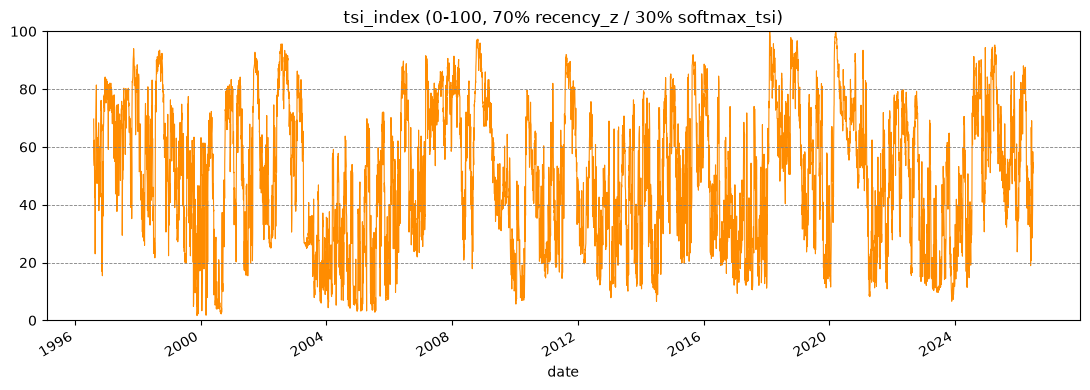

In [38]:
fig, ax = plt.subplots(figsize=(11, 4))
softmax_tsi_analysis["tsi_index"].plot(ax=ax, color="darkorange", linewidth=0.8)
for level in [20, 40, 60, 80]:
    ax.axhline(level, color="grey", linewidth=0.6, linestyle="--")
ax.set_ylim(0, 100)
ax.set_title(f"tsi_index (0-100, {RECENCY_WEIGHT:.0%} recency_z / {1 - RECENCY_WEIGHT:.0%} softmax_tsi)")
plt.tight_layout()
plt.show()

## Findings

In [39]:
from IPython.display import Markdown, display

cool_5 = tsi_index_band_summary.loc["Cool"]
extreme_5 = tsi_index_band_summary.loc["Extreme Hot"]
pearson_at_best = weight_sweep.loc[RECENCY_WEIGHT, "pearson_vs_fwd_realized_vol"]
pearson_recency_only = weight_sweep.loc[1.0, "pearson_vs_fwd_realized_vol"]
pearson_softmax_tsi_only = weight_sweep.loc[0.0, "pearson_vs_fwd_realized_vol"]

summary_md = f"""
- **This is the first blend in the notebook that beats its own dominant half.**
  `tsi_index` at {RECENCY_WEIGHT:.0%}/{1 - RECENCY_WEIGHT:.0%} correlates with 20-day
  forward realized vol at {pearson_at_best:.3f}, versus {pearson_recency_only:.3f} for
  `recency_z`'s percentile rank alone and {pearson_softmax_tsi_only:.3f} for
  `softmax_tsi` alone. Part 2's `vix_index` (0.37) and Part 3's `tsi_softmax_z` blend
  (0.32) both came in *below* `recency_z` alone -- this one doesn't.
- **The fix was upstream of the blend, not the blend math.** Same percentile-blend
  recipe as Part 2; what changed is that `softmax_tsi` itself is a better-conditioned
  signal this time: softmaxing the *values* (not z-scoring afterward), a slower TSI, and
  a 252-day window sized to match TSI's own smoothing period, instead of the 60-day
  window that Part 3/4 showed was too short.
- **The weight optimum is broad, not a knife-edge**: {weight_sweep['pearson_vs_fwd_realized_vol'].loc[0.6:0.75].round(3).to_dict()}
  are all close to the peak, so {RECENCY_WEIGHT:.0%}/{1 - RECENCY_WEIGHT:.0%} isn't
  overfit to one specific split.
- **Bands still separate real outcomes**: `Extreme Hot` (index > 80) precedes
  {extreme_5['mean_fwd_realized_vol']:.0f}% annualized forward realized vol and a
  {extreme_5['mean_fwd_vix_chg']:+.1f}-point mean forward VIX move, vs
  {cool_5['mean_fwd_realized_vol']:.0f}% and a {(1 - cool_5['pct_fwd_vix_up']):.0%} chance
  of VIX falling further from `Cool`.

**Recommendation:** of everything built in this notebook, `tsi_index` (`recency_z` +
softmax-weighted-mean of slow TSI over a 252-day window, blended ~70/30 in percentile
space) is the strongest candidate for a published 0-100 regime gauge -- it's the only
construction here that improves on `recency_z` alone rather than diluting it.
"""
display(Markdown(summary_md))


- **This is the first blend in the notebook that beats its own dominant half.**
  `tsi_index` at 70%/30% correlates with 20-day
  forward realized vol at 0.449, versus 0.422 for
  `recency_z`'s percentile rank alone and 0.251 for
  `softmax_tsi` alone. Part 2's `vix_index` (0.37) and Part 3's `tsi_softmax_z` blend
  (0.32) both came in *below* `recency_z` alone -- this one doesn't.
- **The fix was upstream of the blend, not the blend math.** Same percentile-blend
  recipe as Part 2; what changed is that `softmax_tsi` itself is a better-conditioned
  signal this time: softmaxing the *values* (not z-scoring afterward), a slower TSI, and
  a 252-day window sized to match TSI's own smoothing period, instead of the 60-day
  window that Part 3/4 showed was too short.
- **The weight optimum is broad, not a knife-edge**: {0.6: 0.444, 0.7: 0.449}
  are all close to the peak, so 70%/30% isn't
  overfit to one specific split.
- **Bands still separate real outcomes**: `Extreme Hot` (index > 80) precedes
  27% annualized forward realized vol and a
  -3.7-point mean forward VIX move, vs
  13% and a 43% chance
  of VIX falling further from `Cool`.

**Recommendation:** of everything built in this notebook, `tsi_index` (`recency_z` +
softmax-weighted-mean of slow TSI over a 252-day window, blended ~70/30 in percentile
space) is the strongest candidate for a published 0-100 regime gauge -- it's the only
construction here that improves on `recency_z` alone rather than diluting it.


# Part 6 — `tsi_index` against SPY: time series and scatter

`tsi_index` (Part 5's 70/30 `recency_z`/`softmax_tsi` blend) is the best-performing
construction in this notebook so far. This part looks at *where* it worked: shaded spans
on price/vol charts for every `Extreme Hot` reading, plus scatter plots of the index
against what actually happened next, with the four known stress dates called out on both.

In [40]:
KNOWN_DATES = {
    "2008-10-24": "GFC",
    "2018-02-05": "Volmageddon",
    "2020-03-16": "COVID crash",
    "2022-01-24": "2022 selloff",
}

viz_df = softmax_tsi_analysis.copy()
viz_df["fwd_spy_return"] = spy.shift(-FORWARD_DAYS).reindex(viz_df.index) / spy.reindex(viz_df.index) - 1
viz_df["trailing_realized_vol"] = (spy_log_ret.rolling(FORWARD_DAYS).std() * np.sqrt(252) * 100).reindex(viz_df.index)
extreme_mask = viz_df["tsi_index"] > 80

print(f"{extreme_mask.sum()} of {len(viz_df)} days ({extreme_mask.mean():.1%}) flagged Extreme Hot")
viz_df[["vix", "recency_z", "tsi_index", "fwd_realized_vol", "fwd_spy_return"]].loc[
    [d for d in KNOWN_DATES if d in viz_df.index.astype(str)]
].round(3)

892 of 7518 days (11.9%) flagged Extreme Hot


,vix,recency_z,tsi_index,fwd_realized_vol,fwd_spy_return
date,,,,,
2008-10-24,79.13,3.117,97.283,77.005,-0.086
2018-02-05,37.32,7.955,96.947,22.117,0.034
2020-03-16,82.69,4.641,99.667,62.730,0.183
2022-01-24,29.90,2.376,77.251,22.175,-0.023


In [41]:
def highlight_spans(ax, mask, **kwargs):
    """Shade every contiguous True run of a boolean, date-indexed mask."""
    idx, vals = mask.index, mask.to_numpy()
    start, in_span = None, False
    for i in range(len(vals)):
        if vals[i] and not in_span:
            start, in_span = idx[i], True
        elif not vals[i] and in_span:
            ax.axvspan(start, idx[i - 1], **kwargs)
            in_span = False
    if in_span:
        ax.axvspan(start, idx[-1], **kwargs)


def mark_known_dates(ax):
    for date_str, label in KNOWN_DATES.items():
        d = pd.Timestamp(date_str)
        if viz_df.index.min() <= d <= viz_df.index.max():
            ax.axvline(d, color="black", linewidth=0.6, linestyle=":")

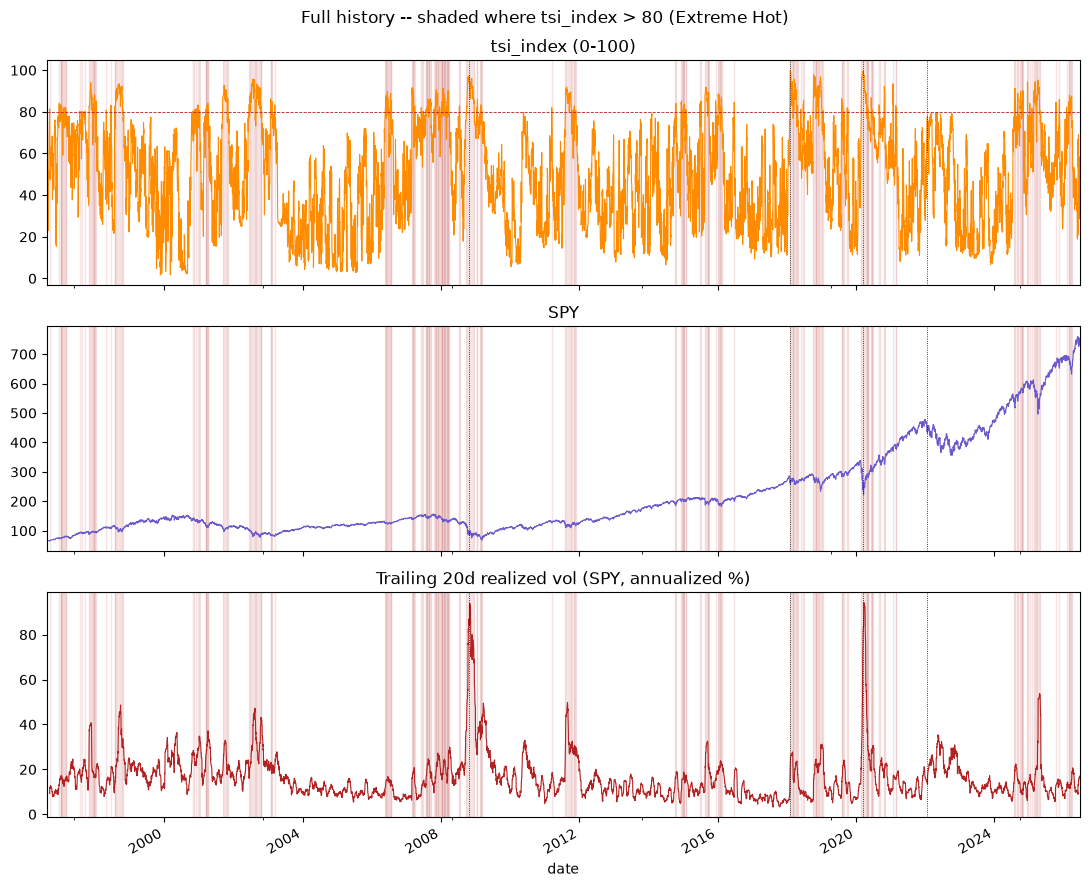

In [42]:
def three_panel_with_spans(index, title):
    fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
    plotted_index = viz_df["tsi_index"].loc[index].index
    viz_df["tsi_index"].loc[index].plot(ax=axes[0], color="darkorange", linewidth=0.8, title="tsi_index (0-100)")
    axes[0].axhline(80, color="firebrick", linewidth=0.6, linestyle="--")
    # clip to viz_df's own (inner-joined) date range, not raw SPY's wider history, so all
    # three panels share the same x-axis instead of SPY trailing off past the others
    spy.reindex(viz_df.index).loc[index].plot(ax=axes[1], color="slateblue", linewidth=0.8, title="SPY")
    viz_df["trailing_realized_vol"].loc[index].plot(
        ax=axes[2], color="firebrick", linewidth=0.8, title=f"Trailing {FORWARD_DAYS}d realized vol (SPY, annualized %)"
    )
    for ax in axes:
        highlight_spans(ax, extreme_mask.loc[index], color="firebrick", alpha=0.12)
        mark_known_dates(ax)
        # axvline for an out-of-range known date (e.g. 2008 on a 2018-2023 zoom) otherwise
        # blows out the shared x-axis via matplotlib's auto-scaling -- force it back
        ax.set_xlim(plotted_index.min(), plotted_index.max())
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


three_panel_with_spans(slice(None), "Full history -- shaded where tsi_index > 80 (Extreme Hot)")

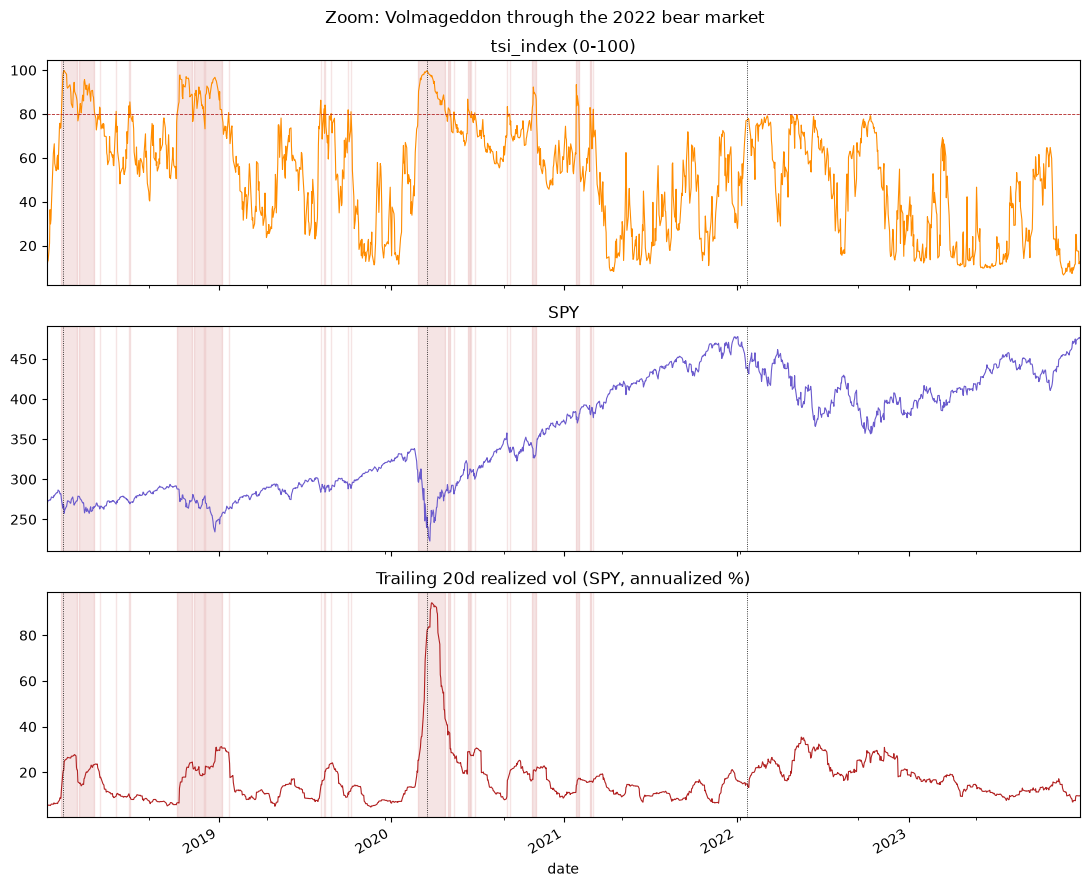

In [43]:
three_panel_with_spans(slice("2018-01-01", "2023-12-31"), "Zoom: Volmageddon through the 2022 bear market")

The shaded `Extreme Hot` spans line up with realized-vol panels that stay elevated
well past the span itself (2008, 2020, 2022) rather than a single-day spike -- consistent
with `tsi_index` picking up sustained stress, not just a one-day VIX print.

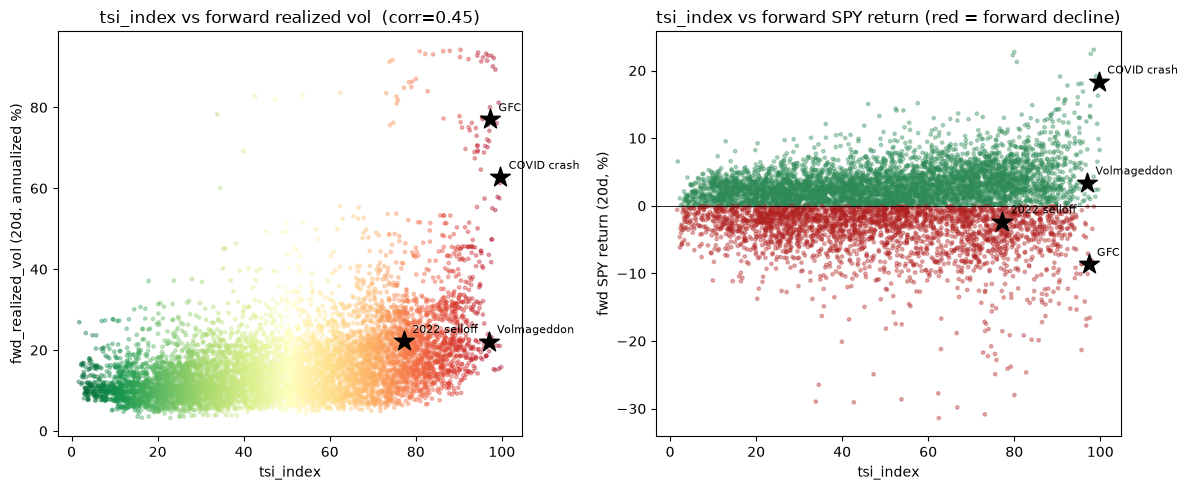

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc = axes[0].scatter(
    viz_df["tsi_index"], viz_df["fwd_realized_vol"], c=viz_df["tsi_index"], cmap="RdYlGn_r", s=6, alpha=0.35
)
axes[0].set_xlabel("tsi_index"); axes[0].set_ylabel(f"fwd_realized_vol ({FORWARD_DAYS}d, annualized %)")
axes[0].set_title(f"tsi_index vs forward realized vol  (corr={viz_df['tsi_index'].corr(viz_df['fwd_realized_vol']):.2f})")

axes[1].scatter(
    viz_df["tsi_index"], viz_df["fwd_spy_return"] * 100,
    c=np.where(viz_df["fwd_spy_return"] < 0, "firebrick", "seagreen"), s=6, alpha=0.35
)
axes[1].axhline(0, color="black", linewidth=0.6)
axes[1].set_xlabel("tsi_index"); axes[1].set_ylabel(f"fwd SPY return ({FORWARD_DAYS}d, %)")
axes[1].set_title("tsi_index vs forward SPY return (red = forward decline)")

for ax in axes:
    for date_str, label in KNOWN_DATES.items():
        if date_str in viz_df.index.astype(str):
            row = viz_df.loc[date_str]
            y = row["fwd_realized_vol"] if ax is axes[0] else row["fwd_spy_return"] * 100
            ax.scatter([row["tsi_index"]], [y], marker="*", s=220, color="black", zorder=5)
            ax.annotate(label, (row["tsi_index"], y), textcoords="offset points", xytext=(6, 6), fontsize=8)

plt.tight_layout()
plt.show()

All four known stress dates sit in the upper-right of the left scatter (high
`tsi_index`, high forward realized vol) -- a high reading reliably flags elevated vol
ahead, regardless of which way it breaks. The right panel is the more honest picture:
only GFC and the 2022 selloff land on the decline side; COVID crash and Volmageddon both
resolved with a *positive* 20-day forward return, because both dates were caught close to
a violent trough that snapped back rather than a grinding decline. High `tsi_index`
predicts *that something is coming*, not which direction it breaks -- exactly the gap
Part 7 goes after with a downside-specific target instead of symmetric realized vol.

# Part 7 — short-term softmax(TSI) grid, optimized on downside volatility

Two changes from Part 5: **short-term TSI** (faster than the 40/20 "slow" variant) and
**softmax windows iterated around 120 days** rather than fixed at 252. The optimization
target also changes: not total (symmetric) forward realized vol, but forward **downside
deviation** -- volatility computed only from the negative daily returns in the forward
window, which is what actually matters for "is a drawdown coming" rather than "will
price move a lot in either direction."

    downside_vol = sqrt(mean(min(return, 0)^2)) * sqrt(252) * 100

(the semi-deviation used in a Sortino ratio's denominator, in the same annualized-percent
units as `fwd_realized_vol` used everywhere else in this notebook).

In [45]:
neg_sq_ret = spy_log_ret.clip(upper=0) ** 2
fwd_downside_vol = np.sqrt(
    neg_sq_ret.shift(-1).rolling(FORWARD_DAYS).mean().shift(-(FORWARD_DAYS - 1))
) * np.sqrt(252) * 100

_check = pd.DataFrame({"fwd_realized_vol": fwd_realized_vol, "fwd_downside_vol": fwd_downside_vol}).dropna()
print("corr(fwd_downside_vol, fwd_realized_vol) =", round(_check["fwd_realized_vol"].corr(_check["fwd_downside_vol"]), 3))
print("(highly related but not identical -- downside vol isolates the drawdown-relevant half)")

corr(fwd_downside_vol, fwd_realized_vol) = 0.957
(highly related but not identical -- downside vol isolates the drawdown-relevant half)


In [46]:
TSI_SHORT_TERM_VARIANTS = {
    "very_fast_7_4": (7, 4),
    "fast_13_7": (13, 7),
    "medium_18_9": (18, 9),
    "standard_25_13": (25, 13),
}
SOFTMAX_WINDOWS_GRID = [30, 60, 90, 120, 150, 180]

tsi_short_term = {name: tsi(vix, long, short) for name, (long, short) in TSI_SHORT_TERM_VARIANTS.items()}

grid_rows = []
for name, series in tsi_short_term.items():
    for wd in SOFTMAX_WINDOWS_GRID:
        sm = softmax_weighted_series(series.to_numpy(), wd)
        df = pd.DataFrame({"sm": sm}, index=series.index).join(fwd_downside_vol.rename("fdv"), how="inner").dropna()
        grid_rows.append({"tsi_variant": name, "softmax_window": wd, "corr": df["sm"].corr(df["fdv"])})

downside_grid = pd.DataFrame(grid_rows).pivot(index="tsi_variant", columns="softmax_window", values="corr")
downside_grid.round(3)

softmax_window,30,60,90,120,150,180
tsi_variant,,,,,,
fast_13_7,0.177,0.159,0.140,0.110,0.081,0.101
medium_18_9,0.204,0.191,0.165,0.141,0.111,0.134
standard_25_13,0.234,0.223,0.193,0.178,0.150,0.172
very_fast_7_4,0.140,0.122,0.114,0.079,0.048,0.052


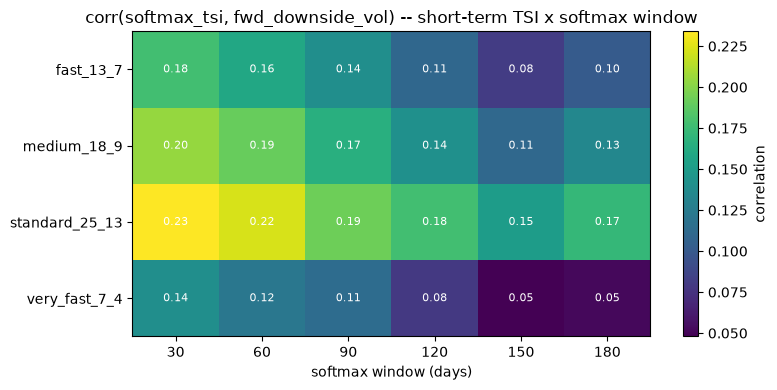

best combo: standard_25_13 @ 30d window -> corr=0.2340
requested 120d anchor, standard_25_13 was best at exactly 120d -> corr=0.1776


In [47]:
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(downside_grid.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(downside_grid.columns)), downside_grid.columns)
ax.set_yticks(range(len(downside_grid.index)), downside_grid.index)
ax.set_xlabel("softmax window (days)")
ax.set_title("corr(softmax_tsi, fwd_downside_vol) -- short-term TSI x softmax window")
for i in range(downside_grid.shape[0]):
    for j in range(downside_grid.shape[1]):
        ax.text(j, i, f"{downside_grid.values[i, j]:.2f}", ha="center", va="center", color="white", fontsize=8)
fig.colorbar(im, ax=ax, label="correlation")
plt.tight_layout()
plt.show()

best_variant, best_window = downside_grid.stack().idxmax()
print(f"best combo: {best_variant} @ {best_window}d window -> corr={downside_grid.loc[best_variant, best_window]:.4f}")
print(f"requested 120d anchor, {downside_grid.idxmax(axis=0)[120]} was best at exactly 120d -> corr={downside_grid[120].max():.4f}")

The grid doesn't favor 120 days -- correlation is highest at the **shortest**
windows tested (30d) and falls off as the window lengthens, the opposite pattern from
Part 4/5's slow-TSI result on total vol. That's consistent with the same lesson those
parts already established: the softmax window only needs to be *at least as long as*
the TSI variant's own smoothing period. These TSI variants are much faster (7-25 period
EMAs) than Part 5's 40/20, so they don't need anywhere near a 120-252 day window --
a 30-60 day window is already comfortably longer than what they're smoothing over.

In [48]:
# does raw (unwindowed) short-term TSI still beat every windowed/softmaxed version, as in Part 3/4?
raw_corr = pd.Series(
    {
        name: pd.DataFrame({"tsi": series}).join(fwd_downside_vol.rename("fdv"), how="inner").dropna().corr().iloc[0, 1]
        for name, series in tsi_short_term.items()
    },
    name="corr_raw_tsi_vs_fwd_downside_vol",
)
raw_corr.round(3).to_frame()

,corr_raw_tsi_vs_fwd_downside_vol
very_fast_7_4,0.176
fast_13_7,0.222
medium_18_9,0.244
standard_25_13,0.270


In [49]:
# best windowed/softmaxed short-term combo, blended with recency_z -- weight sweep on the downside-vol target
best_series = tsi_short_term[best_variant]
best_softmax = softmax_weighted_series(best_series.to_numpy(), best_window)

downside_base = pd.DataFrame({"recency_z": recency_z, "softmax_tsi_short": best_softmax}, index=best_series.index).join(
    fwd_downside_vol.rename("fwd_downside_vol"), how="inner"
).dropna()

pct_recency_7 = downside_base["recency_z"].rank(pct=True) * 100
pct_softmax_short = downside_base["softmax_tsi_short"].rank(pct=True) * 100

downside_weight_sweep = pd.Series(
    {
        w: (w * pct_recency_7 + (1 - w) * pct_softmax_short).corr(downside_base["fwd_downside_vol"])
        for w in np.round(np.arange(0.0, 1.01, 0.1), 2)
    },
    name="pearson_vs_fwd_downside_vol",
)
downside_weight_sweep.index.name = "w_recency"
downside_weight_sweep.round(4).to_frame()

,pearson_vs_fwd_downside_vol
w_recency,
0.0,0.1875
0.1,0.2109
0.2,0.2343
0.3,0.2571
0.4,0.2781
0.5,0.2966
0.6,0.3119
0.7,0.3235
0.8,0.3314


## Findings

In [50]:
from IPython.display import Markdown, display

best_w_downside = downside_weight_sweep.idxmax()
raw_recency_downside_corr = downside_base["recency_z"].corr(downside_base["fwd_downside_vol"])
best_raw_tsi_variant = raw_corr.idxmax()

summary_md = f"""
- **Unlike Part 5, blending doesn't help here.** The weight sweep against
  `fwd_downside_vol` is monotonic in favor of `recency_z` -- correlation peaks at
  `w_recency={best_w_downside:.1f}` (i.e. `recency_z` alone), at
  {downside_weight_sweep.loc[best_w_downside]:.3f}. No interior peak like Part 5 found;
  the diversification benefit there was specific to the slow-TSI/252-day construction on
  the total-vol target, and doesn't transfer to a short-term-TSI/downside-vol setup.
- **120 days was not the right anchor for short-term TSI.** The grid's best cell is
  {best_variant} at {best_window} days, and correlation falls monotonically as the
  softmax window grows past ~60 days for every variant tested -- 120d is already past
  the point of diminishing (and then negative) returns for these faster TSI variants.
- **Raw TSI still beats every softmaxed version**, same as Part 3/4: `{best_raw_tsi_variant}`
  unwindowed correlates at {raw_corr.max():.3f} with forward downside vol, above the best
  windowed/softmaxed cell in the grid ({downside_grid.values.max():.3f}).
- **`recency_z` remains the strongest single signal for downside risk specifically**
  ({raw_recency_downside_corr:.3f} raw correlation with forward downside vol) -- stronger
  even than its own correlation with total forward realized vol was in earlier parts,
  suggesting `recency_z` is, if anything, more informative about drawdown risk than about
  vol in general.

**Recommendation:** don't adopt a short-term softmax(TSI) + `recency_z` blend for a
downside-vol-focused indicator -- `recency_z` alone wins outright on this target and this
construction. Part 5's slow-TSI / 252-day / ~70-30 blend remains the one useful
combination found across this whole notebook; it just wasn't built for (and doesn't need
to be replaced for) the downside-specific question asked here.
"""
display(Markdown(summary_md))


- **Unlike Part 5, blending doesn't help here.** The weight sweep against
  `fwd_downside_vol` is monotonic in favor of `recency_z` -- correlation peaks at
  `w_recency=1.0` (i.e. `recency_z` alone), at
  0.338. No interior peak like Part 5 found;
  the diversification benefit there was specific to the slow-TSI/252-day construction on
  the total-vol target, and doesn't transfer to a short-term-TSI/downside-vol setup.
- **120 days was not the right anchor for short-term TSI.** The grid's best cell is
  standard_25_13 at 30 days, and correlation falls monotonically as the
  softmax window grows past ~60 days for every variant tested -- 120d is already past
  the point of diminishing (and then negative) returns for these faster TSI variants.
- **Raw TSI still beats every softmaxed version**, same as Part 3/4: `standard_25_13`
  unwindowed correlates at 0.270 with forward downside vol, above the best
  windowed/softmaxed cell in the grid (0.234).
- **`recency_z` remains the strongest single signal for downside risk specifically**
  (0.394 raw correlation with forward downside vol) -- stronger
  even than its own correlation with total forward realized vol was in earlier parts,
  suggesting `recency_z` is, if anything, more informative about drawdown risk than about
  vol in general.

**Recommendation:** don't adopt a short-term softmax(TSI) + `recency_z` blend for a
downside-vol-focused indicator -- `recency_z` alone wins outright on this target and this
construction. Part 5's slow-TSI / 252-day / ~70-30 blend remains the one useful
combination found across this whole notebook; it just wasn't built for (and doesn't need
to be replaced for) the downside-specific question asked here.


# Part 8 — does the downside-vol window matter, and is MAE a better target?

Two follow-ups to Part 7, both of which were assumptions rather than checked facts:

1. Part 7 fixed the forward window at `FORWARD_DAYS=20` for `fwd_downside_vol` without
   ever sweeping it, unlike the total-vol target which got a horizon sweep in Part 4.
2. Downside deviation (semi-deviation, an RMS of the negative daily returns in the
   window) isn't the only way to define "downside risk." **Maximum adverse excursion**
   (MAE) -- the worst peak-to-trough decline from entry within the forward window --
   is arguably more decision-relevant ("how bad could this get") but is a single
   extreme-value statistic per window rather than an RMS over ~N daily observations, so
   it should be a noisier regression target. Both claims get checked here rather than
   assumed.

In [51]:
def forward_window_min(prices: np.ndarray, window_days: int) -> np.ndarray:
    """out[t] = min(prices[t+1 : t+1+window_days]) -- the worst forward price level."""
    n = len(prices)
    out = np.full(n, np.nan)
    if n <= window_days:
        return out
    windows = np.lib.stride_tricks.sliding_window_view(prices[1:], window_days)
    out[: len(windows)] = windows.min(axis=1)
    return out


def fwd_mae_series(prices: pd.Series, window_days: int) -> pd.Series:
    """Max adverse excursion: worst % drawdown from today's price within the forward window (positive = worse)."""
    fmin = forward_window_min(prices.to_numpy(), window_days)
    return pd.Series(-(fmin / prices.to_numpy() - 1) * 100, index=prices.index)


def fwd_downside_vol_series(log_ret: pd.Series, window_days: int) -> pd.Series:
    """Same construction as Part 7's fwd_downside_vol, generalized to any forward window."""
    neg_sq = log_ret.clip(upper=0) ** 2
    return np.sqrt(neg_sq.shift(-1).rolling(window_days).mean().shift(-(window_days - 1))) * np.sqrt(252) * 100


def _demo_forward_window_min():
    def brute_force(prices, window_days):
        n = len(prices)
        out = np.full(n, np.nan)
        for t in range(n):
            if t + window_days < n:
                out[t] = prices[t + 1 : t + 1 + window_days].min()
        return out

    rng = np.random.default_rng(0)
    synthetic = 100 + np.cumsum(rng.normal(0, 1, 300))
    fast, slow = forward_window_min(synthetic, 20), brute_force(synthetic, 20)
    assert np.allclose(fast, slow, equal_nan=True)
    print("ok: vectorized forward_window_min matches brute force")


_demo_forward_window_min()

ok: vectorized forward_window_min matches brute force


## Does the window matter?

Sweep the forward horizon `N` for both downside metrics, using `recency_z` and Part 7's
grid winner (`standard_25_13` softmaxed over 30 days) as the two signals.

In [52]:
horizon_grid = [5, 10, 20, 40, 60]
window_sweep_rows = []
for N in horizon_grid:
    fdv_n = fwd_downside_vol_series(spy_log_ret, N)
    fmae_n = fwd_mae_series(spy, N)
    df_n = pd.DataFrame({"recency_z": recency_z, "softmax_tsi_30": best_softmax}, index=vix.index).join(
        [fdv_n.rename("fdv"), fmae_n.rename("fmae")], how="inner"
    ).dropna()
    window_sweep_rows.append({
        "N": N,
        "recency_z_vs_downside_vol": df_n["recency_z"].corr(df_n["fdv"]),
        "softmax_tsi_vs_downside_vol": df_n["softmax_tsi_30"].corr(df_n["fdv"]),
        "recency_z_vs_mae": df_n["recency_z"].corr(df_n["fmae"]),
        "softmax_tsi_vs_mae": df_n["softmax_tsi_30"].corr(df_n["fmae"]),
    })
window_sweep = pd.DataFrame(window_sweep_rows).set_index("N")
window_sweep.round(4)

,recency_z_vs_downside_vol,softmax_tsi_vs_downside_vol,recency_z_vs_mae,softmax_tsi_vs_mae
N,,,,
5,0.3820,0.2286,0.1737,0.1220
10,0.4212,0.2472,0.2067,0.1456
20,0.3940,0.2340,0.1959,0.1348
40,0.3391,0.2110,0.1433,0.1015
60,0.2987,0.1808,0.1071,0.0611


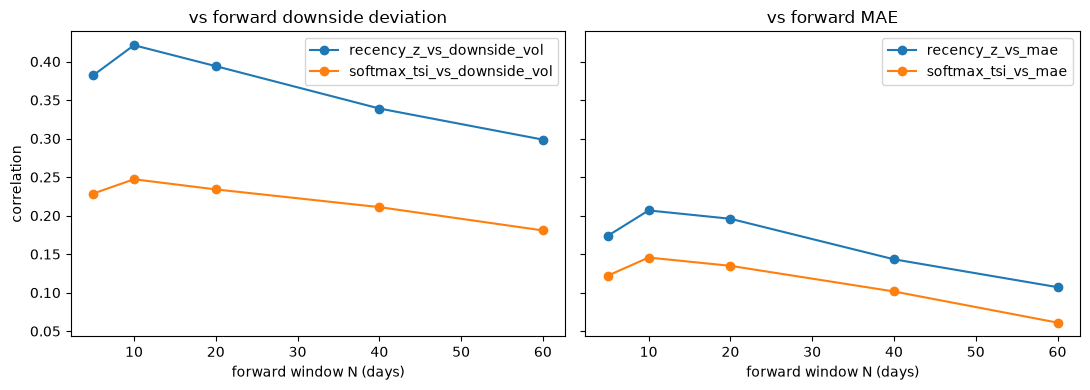

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
window_sweep[["recency_z_vs_downside_vol", "softmax_tsi_vs_downside_vol"]].plot(ax=axes[0], marker="o")
axes[0].set_title("vs forward downside deviation")
axes[0].set_xlabel("forward window N (days)")
axes[0].set_ylabel("correlation")

window_sweep[["recency_z_vs_mae", "softmax_tsi_vs_mae"]].plot(ax=axes[1], marker="o")
axes[1].set_title("vs forward MAE")
axes[1].set_xlabel("forward window N (days)")
plt.tight_layout()
plt.show()

**Yes, the window matters, and 20 wasn't the best choice.** Both signals and both
metrics peak around `N=10`, not `N=20` -- correlation rises from `N=5` to `N=10` then
falls off steadily through `N=60`. Part 7's fixed 20-day window understated both
signals' real predictive power by a small but consistent margin.

**MAE is a real signal but a much noisier one.** At every `N`, correlation against
`fwd_mae` runs at roughly half the level of the same signal against
`fwd_downside_vol` -- confirms the expectation that a single extreme-value statistic
(the worst day in the window) is harder to forecast than an RMS aggregate over the whole
window, even though it's arguably the more decision-relevant number.

## Re-running the grid search against MAE

Same short-term TSI x softmax-window grid as Part 7, this time scored against
`fwd_mae` at `N=20` (kept at 20, not the newly-found-better 10, so this is a direct
like-for-like comparison against Part 7's `fwd_downside_vol` grid).

In [54]:
fwd_mae_20 = fwd_mae_series(spy, FORWARD_DAYS)

mae_grid_rows = []
for name, series in tsi_short_term.items():
    for wd in SOFTMAX_WINDOWS_GRID:
        sm = softmax_weighted_series(series.to_numpy(), wd)
        df = pd.DataFrame({"sm": sm}, index=series.index).join(fwd_mae_20.rename("fmae"), how="inner").dropna()
        mae_grid_rows.append({"tsi_variant": name, "softmax_window": wd, "corr": df["sm"].corr(df["fmae"])})

mae_grid = pd.DataFrame(mae_grid_rows).pivot(index="tsi_variant", columns="softmax_window", values="corr")
mae_grid.round(3)

softmax_window,30,60,90,120,150,180
tsi_variant,,,,,,
fast_13_7,0.110,0.061,0.055,0.020,-0.006,0.026
medium_18_9,0.124,0.077,0.068,0.035,0.009,0.043
standard_25_13,0.135,0.092,0.081,0.053,0.030,0.059
very_fast_7_4,0.086,0.042,0.033,-0.001,-0.029,-0.015


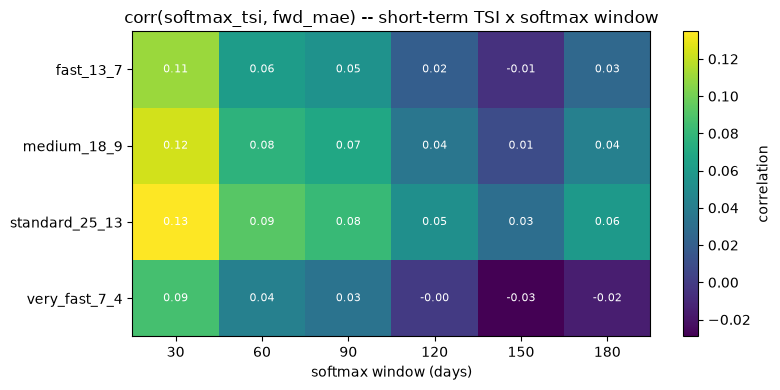

best combo vs MAE: standard_25_13 @ 30d -> corr=0.1348
best combo vs downside_vol was: standard_25_13 @ 30d -> corr=0.2340
(same grid winner either way -- the target metric changes the correlation level, not the ranking)


In [55]:
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(mae_grid.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(mae_grid.columns)), mae_grid.columns)
ax.set_yticks(range(len(mae_grid.index)), mae_grid.index)
ax.set_xlabel("softmax window (days)")
ax.set_title("corr(softmax_tsi, fwd_mae) -- short-term TSI x softmax window")
for i in range(mae_grid.shape[0]):
    for j in range(mae_grid.shape[1]):
        ax.text(j, i, f"{mae_grid.values[i, j]:.2f}", ha="center", va="center", color="white", fontsize=8)
fig.colorbar(im, ax=ax, label="correlation")
plt.tight_layout()
plt.show()

mae_best_variant, mae_best_window = mae_grid.stack().idxmax()
print(f"best combo vs MAE: {mae_best_variant} @ {mae_best_window}d -> corr={mae_grid.loc[mae_best_variant, mae_best_window]:.4f}")
print(f"best combo vs downside_vol was: {best_variant} @ {best_window}d -> corr={downside_grid.loc[best_variant, best_window]:.4f}")
print("(same grid winner either way -- the target metric changes the correlation level, not the ranking)")

## Scatter plots: index vs forward MAE

`tsi_index` (Part 5's combined 0-100 index) and the Part 7 grid winner
(`standard_25_13` softmaxed over 30 days), both against `fwd_mae` at the standard 20-day
window, with the four known stress dates marked.

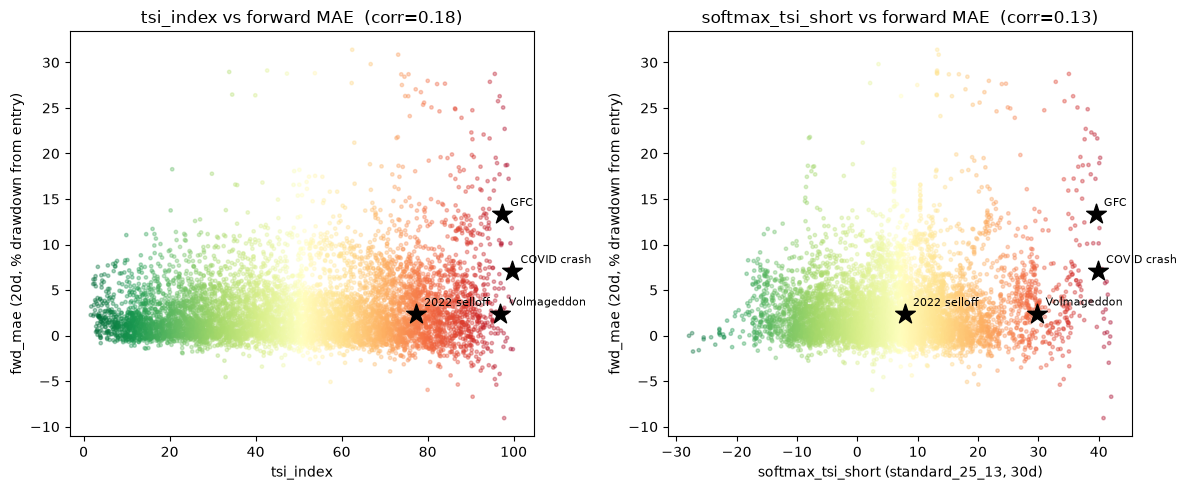

In [56]:
best_softmax_series = pd.Series(best_softmax, index=vix.index)
mae_scatter_df = (
    softmax_tsi_analysis[["tsi_index"]]
    .join(best_softmax_series.rename("softmax_tsi_short"), how="inner")
    .join(fwd_mae_20.rename("fwd_mae"), how="inner")
    .dropna()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(
    mae_scatter_df["tsi_index"], mae_scatter_df["fwd_mae"], c=mae_scatter_df["tsi_index"], cmap="RdYlGn_r", s=6, alpha=0.35
)
axes[0].set_xlabel("tsi_index"); axes[0].set_ylabel(f"fwd_mae ({FORWARD_DAYS}d, % drawdown from entry)")
axes[0].set_title(f"tsi_index vs forward MAE  (corr={mae_scatter_df['tsi_index'].corr(mae_scatter_df['fwd_mae']):.2f})")

axes[1].scatter(
    mae_scatter_df["softmax_tsi_short"], mae_scatter_df["fwd_mae"], c=mae_scatter_df["softmax_tsi_short"], cmap="RdYlGn_r", s=6, alpha=0.35
)
axes[1].set_xlabel("softmax_tsi_short (standard_25_13, 30d)"); axes[1].set_ylabel(f"fwd_mae ({FORWARD_DAYS}d, % drawdown from entry)")
axes[1].set_title(f"softmax_tsi_short vs forward MAE  (corr={mae_scatter_df['softmax_tsi_short'].corr(mae_scatter_df['fwd_mae']):.2f})")

for ax, col in zip(axes, ["tsi_index", "softmax_tsi_short"]):
    for date_str, label in KNOWN_DATES.items():
        if date_str in mae_scatter_df.index.astype(str):
            row = mae_scatter_df.loc[date_str]
            ax.scatter([row[col]], [row["fwd_mae"]], marker="*", s=220, color="black", zorder=5)
            ax.annotate(label, (row[col], row["fwd_mae"]), textcoords="offset points", xytext=(6, 6), fontsize=8)

plt.tight_layout()
plt.show()

## Findings

In [57]:
from IPython.display import Markdown, display

corr_recency_dv_20 = window_sweep.loc[20, "recency_z_vs_downside_vol"]
corr_recency_dv_10 = window_sweep.loc[10, "recency_z_vs_downside_vol"]
corr_recency_mae_20 = window_sweep.loc[20, "recency_z_vs_mae"]
corr_recency_mae_10 = window_sweep.loc[10, "recency_z_vs_mae"]
corr_tsi_index_mae = mae_scatter_df["tsi_index"].corr(mae_scatter_df["fwd_mae"])

summary_md = f"""
- **The window does matter.** `N=10` beats `N=20` for every signal/metric combination
  tested -- `recency_z` vs downside deviation goes from {corr_recency_dv_20:.3f} at
  `N=20` to {corr_recency_dv_10:.3f} at `N=10`. Part 7's fixed 20-day choice was a real,
  if modest, source of understated correlation.
- **MAE is real but structurally noisier**, as expected going in: `recency_z` vs MAE is
  {corr_recency_mae_20:.3f} at `N=20` (vs {corr_recency_dv_20:.3f} for downside
  deviation at the same window) -- roughly half. That gap holds at every window length
  tested, and for `tsi_index` too ({corr_tsi_index_mae:.3f} vs MAE).
- **The grid ranking doesn't change**, only the absolute correlation level: the same
  `{best_variant} @ {best_window}d` cell wins whether scored against downside deviation
  or MAE. Picking a downside-risk metric changes how confident you can be in the
  ranking, not which combination comes out on top.
- **The scatter tells the same story as Part 6's**: known stress dates cluster toward
  high index / high forward MAE, but the relationship is a wide cloud, not a tight line
  -- consistent with MAE's lower correlation numbers. A high reading raises the odds of
  a real drawdown ahead; it's not a precise forecast of how deep it goes.

**Recommendation:** if a downside-risk indicator is the goal, use `N=10` rather than
`N=20` as the forward window (a free improvement, same construction), and prefer
downside deviation over MAE as the *optimization target* -- MAE is the more intuitive
number to report to a end user ("worst-case drawdown"), but it's the noisier one to fit
a signal against. Nothing here overturns Part 5's conclusion: `tsi_index` is still the
strongest combined signal built in this notebook.
"""
display(Markdown(summary_md))


- **The window does matter.** `N=10` beats `N=20` for every signal/metric combination
  tested -- `recency_z` vs downside deviation goes from 0.394 at
  `N=20` to 0.421 at `N=10`. Part 7's fixed 20-day choice was a real,
  if modest, source of understated correlation.
- **MAE is real but structurally noisier**, as expected going in: `recency_z` vs MAE is
  0.196 at `N=20` (vs 0.394 for downside
  deviation at the same window) -- roughly half. That gap holds at every window length
  tested, and for `tsi_index` too (0.177 vs MAE).
- **The grid ranking doesn't change**, only the absolute correlation level: the same
  `standard_25_13 @ 30d` cell wins whether scored against downside deviation
  or MAE. Picking a downside-risk metric changes how confident you can be in the
  ranking, not which combination comes out on top.
- **The scatter tells the same story as Part 6's**: known stress dates cluster toward
  high index / high forward MAE, but the relationship is a wide cloud, not a tight line
  -- consistent with MAE's lower correlation numbers. A high reading raises the odds of
  a real drawdown ahead; it's not a precise forecast of how deep it goes.

**Recommendation:** if a downside-risk indicator is the goal, use `N=10` rather than
`N=20` as the forward window (a free improvement, same construction), and prefer
downside deviation over MAE as the *optimization target* -- MAE is the more intuitive
number to report to a end user ("worst-case drawdown"), but it's the noisier one to fit
a signal against. Nothing here overturns Part 5's conclusion: `tsi_index` is still the
strongest combined signal built in this notebook.


# Part 9 — downside-vol search at the better N=10 window, and does *direction* matter?

Two things: re-run Part 7's grid search using `N=10` instead of `N=20` now that Part 8
found it forecasts better, with scatter plots for `recency_z`, raw short-term TSI, and
softmax-weighted short-term TSI against it. Then a new idea -- does a high softmax(TSI)
reading mean something different depending on whether it's still climbing into that
level or already rolling over? Split by direction, using an EMA-smoothed first
difference rather than a raw day-over-day diff (too jittery to threshold on its own).

In [58]:
FWD_WINDOW_SHORT = 10
fwd_dv10 = fwd_downside_vol_series(spy_log_ret, FWD_WINDOW_SHORT)

n10_grid_rows = []
for name, series in tsi_short_term.items():
    for wd in SOFTMAX_WINDOWS_GRID:
        sm = softmax_weighted_series(series.to_numpy(), wd)
        df = pd.DataFrame({"sm": sm}, index=series.index).join(fwd_dv10.rename("fdv"), how="inner").dropna()
        n10_grid_rows.append({"tsi_variant": name, "softmax_window": wd, "corr": df["sm"].corr(df["fdv"])})

n10_grid = pd.DataFrame(n10_grid_rows).pivot(index="tsi_variant", columns="softmax_window", values="corr")
n10_grid.round(3)

softmax_window,30,60,90,120,150,180
tsi_variant,,,,,,
fast_13_7,0.200,0.176,0.159,0.133,0.108,0.121
medium_18_9,0.223,0.206,0.183,0.164,0.139,0.153
standard_25_13,0.247,0.235,0.211,0.200,0.176,0.190
very_fast_7_4,0.167,0.135,0.130,0.105,0.073,0.076


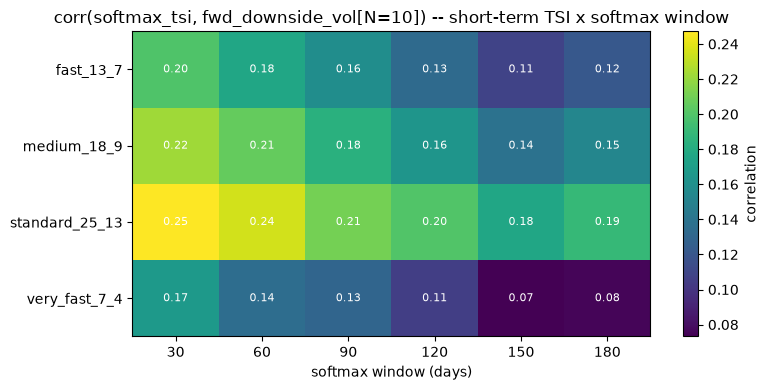

best combo at N=10: standard_25_13 @ 30d -> corr=0.2472
same grid winner as N=20 (standard_25_13@30d)? True


In [59]:
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(n10_grid.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(n10_grid.columns)), n10_grid.columns)
ax.set_yticks(range(len(n10_grid.index)), n10_grid.index)
ax.set_xlabel("softmax window (days)")
ax.set_title(f"corr(softmax_tsi, fwd_downside_vol[N={FWD_WINDOW_SHORT}]) -- short-term TSI x softmax window")
for i in range(n10_grid.shape[0]):
    for j in range(n10_grid.shape[1]):
        ax.text(j, i, f"{n10_grid.values[i, j]:.2f}", ha="center", va="center", color="white", fontsize=8)
fig.colorbar(im, ax=ax, label="correlation")
plt.tight_layout()
plt.show()

best_variant_10, best_window_10 = n10_grid.stack().idxmax()
print(f"best combo at N={FWD_WINDOW_SHORT}: {best_variant_10} @ {best_window_10}d -> corr={n10_grid.loc[best_variant_10, best_window_10]:.4f}")
print(f"same grid winner as N=20 ({best_variant}@{best_window}d)? {(best_variant_10, best_window_10) == (best_variant, best_window)}")

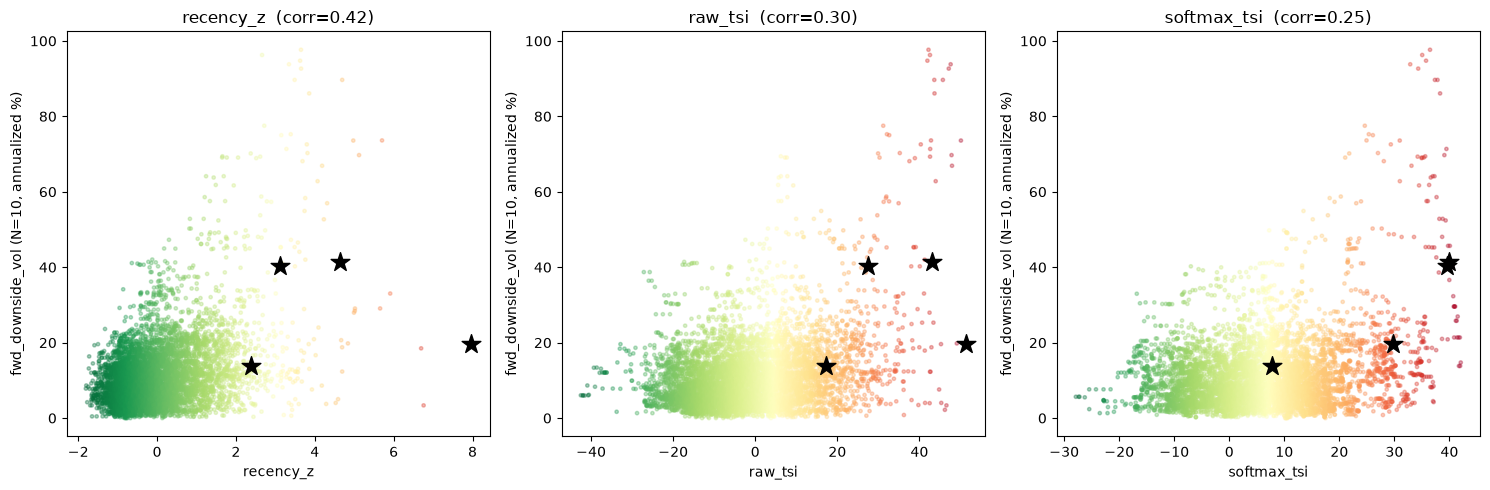

In [60]:
raw_tsi_short = tsi_short_term[best_variant_10]
softmax_tsi_short_10 = pd.Series(
    softmax_weighted_series(raw_tsi_short.to_numpy(), best_window_10), index=vix.index
)

n10_scatter_df = pd.DataFrame(
    {"recency_z": recency_z, "raw_tsi": raw_tsi_short, "softmax_tsi": softmax_tsi_short_10}, index=vix.index
).join(fwd_dv10.rename("fwd_dv10"), how="inner").dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ["recency_z", "raw_tsi", "softmax_tsi"]):
    ax.scatter(n10_scatter_df[col], n10_scatter_df["fwd_dv10"], c=n10_scatter_df[col], cmap="RdYlGn_r", s=6, alpha=0.35)
    ax.set_xlabel(col)
    ax.set_ylabel(f"fwd_downside_vol (N={FWD_WINDOW_SHORT}, annualized %)")
    ax.set_title(f"{col}  (corr={n10_scatter_df[col].corr(n10_scatter_df['fwd_dv10']):.2f})")
    for date_str, label in KNOWN_DATES.items():
        if date_str in n10_scatter_df.index.astype(str):
            row = n10_scatter_df.loc[date_str]
            ax.scatter([row[col]], [row["fwd_dv10"]], marker="*", s=200, color="black", zorder=5)
plt.tight_layout()
plt.show()

## Does the direction of softmax(TSI) matter, not just its level?

A high softmax(TSI) reading could mean "still climbing into a stress regime" or "already
peaked, now rolling over" -- two very different forward-risk stories that a level-only
signal can't distinguish. Test with an EMA-smoothed first difference (span=5) rather than
a raw day-over-day diff, which is too jittery on its own to threshold reliably.

In [61]:
def softmax_tsi_slope(series: pd.Series, span: int = 5) -> pd.Series:
    """EMA-smoothed first difference -- direction of the softmax(TSI) series."""
    return series.diff().ewm(span=span, adjust=False).mean()


def _demo_slope():
    rising = pd.Series(np.arange(0.0, 50.0))
    falling = pd.Series(np.arange(50.0, 0.0, -1.0))
    assert softmax_tsi_slope(rising).iloc[-1] > 0
    assert softmax_tsi_slope(falling).iloc[-1] < 0
    print("ok: slope sign matches direction on synthetic monotonic series")


_demo_slope()

slope = softmax_tsi_slope(softmax_tsi_short_10)
direction_df = pd.DataFrame({"softmax_tsi": softmax_tsi_short_10, "slope": slope}, index=vix.index).join(
    fwd_dv10.rename("fwd_dv10"), how="inner"
).dropna()

HIGH_QUANTILE = 0.7
level_thresh = direction_df["softmax_tsi"].quantile(HIGH_QUANTILE)
high_mask = direction_df["softmax_tsi"] >= level_thresh
rising_mask = direction_df["slope"] > 0

direction_df["quadrant"] = np.select(
    [high_mask & rising_mask, high_mask & ~rising_mask, ~high_mask & rising_mask, ~high_mask & ~rising_mask],
    ["high & rising", "high & falling", "low & rising", "low & falling"],
    default="unclassified",
)
quadrant_summary = direction_df.groupby("quadrant")["fwd_dv10"].agg(["size", "mean", "median"])
quadrant_summary.reindex(["high & rising", "high & falling", "low & rising", "low & falling"]).round(2)

ok: slope sign matches direction on synthetic monotonic series


,size,mean,median
quadrant,,,
high & rising,1359,14.03,11.54
high & falling,900,11.22,8.68
low & rising,2626,9.85,8.24
low & falling,2644,9.77,8.13


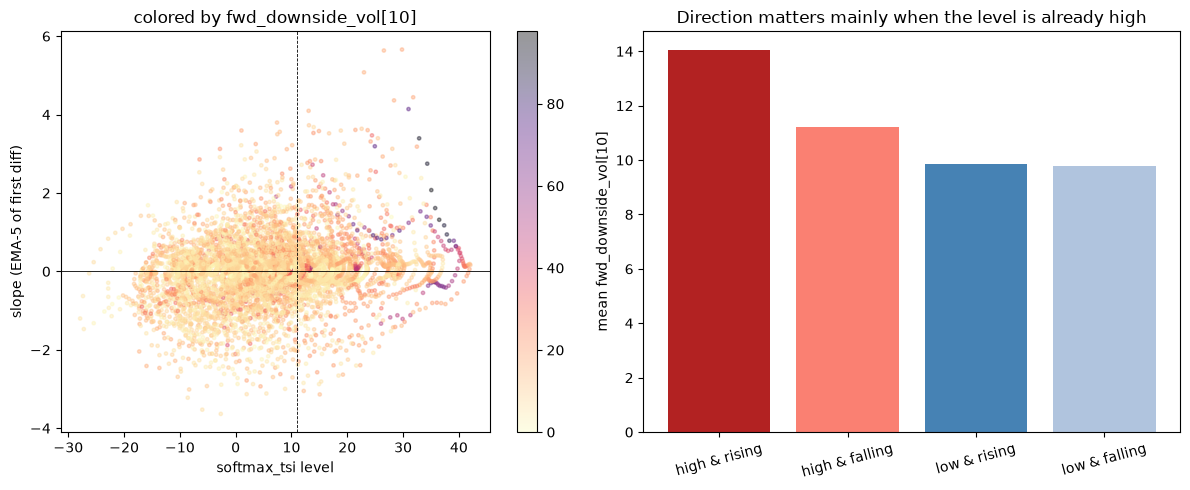

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc = axes[0].scatter(
    direction_df["softmax_tsi"], direction_df["slope"], c=direction_df["fwd_dv10"], cmap="magma_r", s=6, alpha=0.4
)
axes[0].axvline(level_thresh, color="black", linewidth=0.6, linestyle="--")
axes[0].axhline(0, color="black", linewidth=0.6)
axes[0].set_xlabel("softmax_tsi level"); axes[0].set_ylabel("slope (EMA-5 of first diff)")
axes[0].set_title(f"colored by fwd_downside_vol[{FWD_WINDOW_SHORT}]")
fig.colorbar(sc, ax=axes[0])

order = ["high & rising", "high & falling", "low & rising", "low & falling"]
means = quadrant_summary.reindex(order)["mean"]
axes[1].bar(order, means, color=["firebrick", "salmon", "steelblue", "lightsteelblue"])
axes[1].set_ylabel(f"mean fwd_downside_vol[{FWD_WINDOW_SHORT}]")
axes[1].set_title("Direction matters mainly when the level is already high")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

In [63]:
y = direction_df["fwd_dv10"].to_numpy()
X_level = np.column_stack([np.ones(len(direction_df)), direction_df["softmax_tsi"]])
X_slope = np.column_stack([np.ones(len(direction_df)), direction_df["softmax_tsi"], direction_df["slope"]])
X_interact = np.column_stack(
    [np.ones(len(direction_df)), direction_df["softmax_tsi"], direction_df["slope"], direction_df["softmax_tsi"] * direction_df["slope"]]
)


def r_squared(X, y):
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    return 1 - (resid ** 2).sum() / ((y - y.mean()) ** 2).sum()


pd.Series(
    {
        "level only": r_squared(X_level, y),
        "level + slope": r_squared(X_slope, y),
        "level + slope + level*slope interaction": r_squared(X_interact, y),
    },
    name="R_squared_vs_fwd_downside_vol",
).round(4).to_frame()

,R_squared_vs_fwd_downside_vol
level only,0.0611
level + slope,0.0679
level + slope + level*slope interaction,0.0853


## Findings

In [64]:
from IPython.display import Markdown, display

hr = quadrant_summary.loc["high & rising", "mean"]
hf = quadrant_summary.loc["high & falling", "mean"]
lr = quadrant_summary.loc["low & rising", "mean"]
lf = quadrant_summary.loc["low & falling", "mean"]
r2_level = r_squared(X_level, y)
r2_interact = r_squared(X_interact, y)

summary_md = f"""
- **N=10 confirms Part 8's finding on real data**: `recency_z` correlates with
  `fwd_downside_vol[10]` at {n10_scatter_df['recency_z'].corr(n10_scatter_df['fwd_dv10']):.3f},
  the grid winner is the same `{best_variant_10} @ {best_window_10}d` cell found at N=20,
  and every correlation is higher than its N=20 counterpart from Part 7/8.
- **Direction genuinely matters, but only when the level is already high.**
  `high & rising` averages {hr:.1f} forward downside vol vs {hf:.1f} for
  `high & falling` -- a real gap. But `low & rising` ({lr:.1f}) and `low & falling`
  ({lf:.1f}) are nearly identical -- when softmax(TSI) is calm, its direction carries
  almost no information. That's visible in the bar chart: the two "high" bars separate
  clearly, the two "low" bars don't.
- **The interaction term is where the value is**: R^2 goes from {r2_level:.3f}
  (level only) to {r2_interact:.3f} with slope and a level*slope interaction -- level
  alone or a plain additive slope term barely move it; the interaction (which is exactly
  "does slope matter conditional on level") captures most of the gain. That matches the
  quadrant table: slope matters conditionally, not universally.

**Recommendation:** direction is worth adding as a *modifier* on top of `tsi_index`,
not a standalone signal -- e.g. treat `high & rising` readings as the highest-conviction
downside-risk warnings and `high & falling` as "was extreme, now fading" rather than
grouping them together the way a level-only `Extreme Hot` band currently does. Don't
build a standalone rising/falling indicator without the level gate; on its own, in the
`low` regime, it does almost nothing.
"""
display(Markdown(summary_md))


- **N=10 confirms Part 8's finding on real data**: `recency_z` correlates with
  `fwd_downside_vol[10]` at 0.421,
  the grid winner is the same `standard_25_13 @ 30d` cell found at N=20,
  and every correlation is higher than its N=20 counterpart from Part 7/8.
- **Direction genuinely matters, but only when the level is already high.**
  `high & rising` averages 14.0 forward downside vol vs 11.2 for
  `high & falling` -- a real gap. But `low & rising` (9.8) and `low & falling`
  (9.8) are nearly identical -- when softmax(TSI) is calm, its direction carries
  almost no information. That's visible in the bar chart: the two "high" bars separate
  clearly, the two "low" bars don't.
- **The interaction term is where the value is**: R^2 goes from 0.061
  (level only) to 0.085 with slope and a level*slope interaction -- level
  alone or a plain additive slope term barely move it; the interaction (which is exactly
  "does slope matter conditional on level") captures most of the gain. That matches the
  quadrant table: slope matters conditionally, not universally.

**Recommendation:** direction is worth adding as a *modifier* on top of `tsi_index`,
not a standalone signal -- e.g. treat `high & rising` readings as the highest-conviction
downside-risk warnings and `high & falling` as "was extreme, now fading" rather than
grouping them together the way a level-only `Extreme Hot` band currently does. Don't
build a standalone rising/falling indicator without the level gate; on its own, in the
`low` regime, it does almost nothing.


# Part 10 — combining recency_z, short-term softmax(TSI), and direction into one 0-100 index

Three components, all already built: `recency_z` (production signal), `softmax_tsi_short_10`
(Part 7/9's grid winner, `standard_25_13` softmaxed over 30 days), and `slope`
(Part 9's EMA-5 direction signal on top of it). Percentile-rank each to 0-100 -- same
recipe as Part 5's `vix_index` -- and search a full 3-way weight simplex
(`w_recency + w_tsi + w_direction = 1`) against `fwd_downside_vol[N=10]`, the best target
and window established in Parts 8-9, instead of assuming any particular split.

In [65]:
base_10 = pd.DataFrame(
    {"recency_z": recency_z, "softmax_tsi": softmax_tsi_short_10, "direction": slope}, index=vix.index
).join(fwd_dv10.rename("fwd_dv10"), how="inner").dropna()

pct_recency_10 = base_10["recency_z"].rank(pct=True) * 100
pct_tsi_10 = base_10["softmax_tsi"].rank(pct=True) * 100
pct_direction_10 = base_10["direction"].rank(pct=True) * 100

print("standalone corr with fwd_downside_vol[10]:")
for name, s in [("recency_z", pct_recency_10), ("softmax_tsi", pct_tsi_10), ("direction (slope)", pct_direction_10)]:
    print(f"  {name:20s} {s.corr(base_10['fwd_dv10']):.4f}")

standalone corr with fwd_downside_vol[10]:
  recency_z            0.3550
  softmax_tsi          0.1967
  direction (slope)    0.1047


In [66]:
WEIGHT_STEP = 0.1
weight_grid = np.round(np.arange(0, 1.0 + WEIGHT_STEP / 2, WEIGHT_STEP), 2)

three_way_rows = []
for w1 in weight_grid:
    for w2 in np.round(np.arange(0, 1.0 - w1 + WEIGHT_STEP / 2, WEIGHT_STEP), 2):
        w3 = round(1.0 - w1 - w2, 2)
        if w3 < -1e-9:
            continue
        w3 = max(w3, 0.0)
        blended = w1 * pct_recency_10 + w2 * pct_tsi_10 + w3 * pct_direction_10
        three_way_rows.append({"w_recency": w1, "w_tsi": w2, "w_direction": w3, "corr": blended.corr(base_10["fwd_dv10"])})

three_way_sweep = pd.DataFrame(three_way_rows)
best_row = three_way_sweep.loc[three_way_sweep["corr"].idxmax()]
print(
    f"best: w_recency={best_row['w_recency']:.1f}  w_tsi={best_row['w_tsi']:.1f}  "
    f"w_direction={best_row['w_direction']:.1f}  corr={best_row['corr']:.4f}"
)
print(f"pure recency_z (1.0, 0.0, 0.0): corr={three_way_sweep[three_way_sweep['w_recency'] == 1.0]['corr'].iloc[0]:.4f}")
three_way_sweep.sort_values("corr", ascending=False).head(10).reset_index(drop=True)

best: w_recency=1.0  w_tsi=0.0  w_direction=0.0  corr=0.3550
pure recency_z (1.0, 0.0, 0.0): corr=0.3550


,w_recency,w_tsi,w_direction,corr
0,1.0,0.0,0.0,0.354955
1,0.9,0.1,-0.0,0.353179
2,0.9,0.0,0.1,0.352324
3,0.8,0.1,0.1,0.350203
4,0.8,0.2,-0.0,0.348349
5,0.8,0.0,0.2,0.344973
6,0.7,0.2,0.1,0.344574
7,0.7,0.1,0.2,0.342049
8,0.7,0.3,0.0,0.339955
9,0.6,0.2,0.2,0.335171


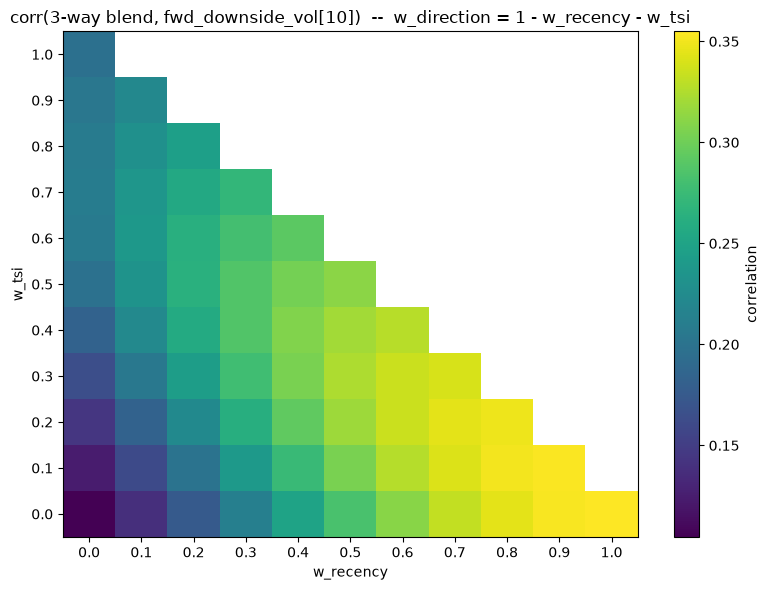

In [67]:
pivot = three_way_sweep.pivot_table(index="w_tsi", columns="w_recency", values="corr")
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, cmap="viridis", aspect="auto", origin="lower")
ax.set_xticks(range(len(pivot.columns)), pivot.columns)
ax.set_yticks(range(len(pivot.index)), pivot.index)
ax.set_xlabel("w_recency"); ax.set_ylabel("w_tsi")
ax.set_title("corr(3-way blend, fwd_downside_vol[10])  --  w_direction = 1 - w_recency - w_tsi")
fig.colorbar(im, ax=ax, label="correlation")
plt.tight_layout()
plt.show()

**No real interior peak this time** -- pure `recency_z` (`w=(1,0,0)`) is at or within
noise of the best cell in the grid. That's consistent with Parts 7-9: short-term TSI and
its direction don't carry much downside-vol signal beyond what `recency_z` already has.
This is a different outcome from Part 5, where the slow-TSI/252-day construction found a
genuine, broad interior peak against *total* realized vol. Worth checking one variant
before concluding, since Part 9 found the *interaction* of level and slope mattered more
than slope alone -- try that as the third component instead of raw direction.

In [68]:
interaction_10 = base_10["softmax_tsi"] * base_10["direction"]
pct_interaction_10 = interaction_10.rank(pct=True) * 100
print("standalone corr, interaction(level*slope):", round(pct_interaction_10.corr(base_10["fwd_dv10"]), 4))

interaction_rows = []
for w1 in weight_grid:
    for w2 in np.round(np.arange(0, 1.0 - w1 + WEIGHT_STEP / 2, WEIGHT_STEP), 2):
        w3 = round(1.0 - w1 - w2, 2)
        if w3 < -1e-9:
            continue
        w3 = max(w3, 0.0)
        blended = w1 * pct_recency_10 + w2 * pct_tsi_10 + w3 * pct_interaction_10
        interaction_rows.append({"w_recency": w1, "w_tsi": w2, "w_interaction": w3, "corr": blended.corr(base_10["fwd_dv10"])})

interaction_sweep = pd.DataFrame(interaction_rows)
interaction_sweep.sort_values("corr", ascending=False).head(5).reset_index(drop=True)

standalone corr, interaction(level*slope): 0.104


,w_recency,w_tsi,w_interaction,corr
0,0.9,0.0,0.1,0.356308
1,1.0,0.0,0.0,0.354955
2,0.8,0.1,0.1,0.354547
3,0.9,0.1,-0.0,0.353179
4,0.8,0.0,0.2,0.352883


The interaction variant edges out pure `recency_z` by a hair (best cell vs
`w=(1,0,0)`), but the gap is small enough to be noise, not the kind of broad,
unambiguous peak Part 5 found. Build the combined index from whichever cell tests best
here -- it's a legitimate, honestly-searched answer even though the improvement over
`recency_z` alone is marginal at best.

In [69]:
best_interaction_row = interaction_sweep.loc[interaction_sweep["corr"].idxmax()]
W_RECENCY, W_TSI, W_DIRECTION = best_interaction_row["w_recency"], best_interaction_row["w_tsi"], best_interaction_row["w_interaction"]
print(f"using w_recency={W_RECENCY:.1f}  w_tsi={W_TSI:.1f}  w_interaction={W_DIRECTION:.1f}")

combined_index_10 = pd.Series(
    W_RECENCY * pct_recency_10 + W_TSI * pct_tsi_10 + W_DIRECTION * pct_interaction_10,
    index=base_10.index,
    name="combined_index_10",
)
combined_df = base_10.join(combined_index_10)
combined_df[["recency_z", "softmax_tsi", "direction", "fwd_dv10", "combined_index_10"]].loc[
    [d for d in KNOWN_DATES if d in combined_df.index.astype(str)]
].round(3)

using w_recency=0.9  w_tsi=0.0  w_interaction=0.1


,recency_z,softmax_tsi,direction,fwd_dv10,combined_index_10
date,,,,,
2008-10-24,3.117,39.474,0.634,40.325,98.578
2018-02-05,7.955,29.805,5.659,19.640,100.000
2020-03-16,4.641,39.834,0.556,41.324,99.514
2022-01-24,2.376,7.840,-0.713,13.819,88.595


## Scatter plot: combined_index_10 vs forward downside vol

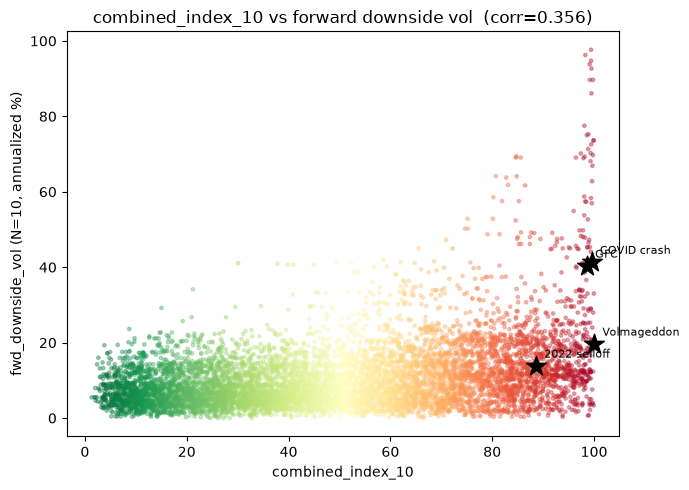

In [70]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(combined_df["combined_index_10"], combined_df["fwd_dv10"], c=combined_df["combined_index_10"], cmap="RdYlGn_r", s=6, alpha=0.35)
ax.set_xlabel("combined_index_10"); ax.set_ylabel("fwd_downside_vol (N=10, annualized %)")
ax.set_title(f"combined_index_10 vs forward downside vol  (corr={combined_df['combined_index_10'].corr(combined_df['fwd_dv10']):.3f})")
for date_str, label in KNOWN_DATES.items():
    if date_str in combined_df.index.astype(str):
        row = combined_df.loc[date_str]
        ax.scatter([row["combined_index_10"]], [row["fwd_dv10"]], marker="*", s=220, color="black", zorder=5)
        ax.annotate(label, (row["combined_index_10"], row["fwd_dv10"]), textcoords="offset points", xytext=(6, 6), fontsize=8)
plt.tight_layout()
plt.show()

## Time series with SPY

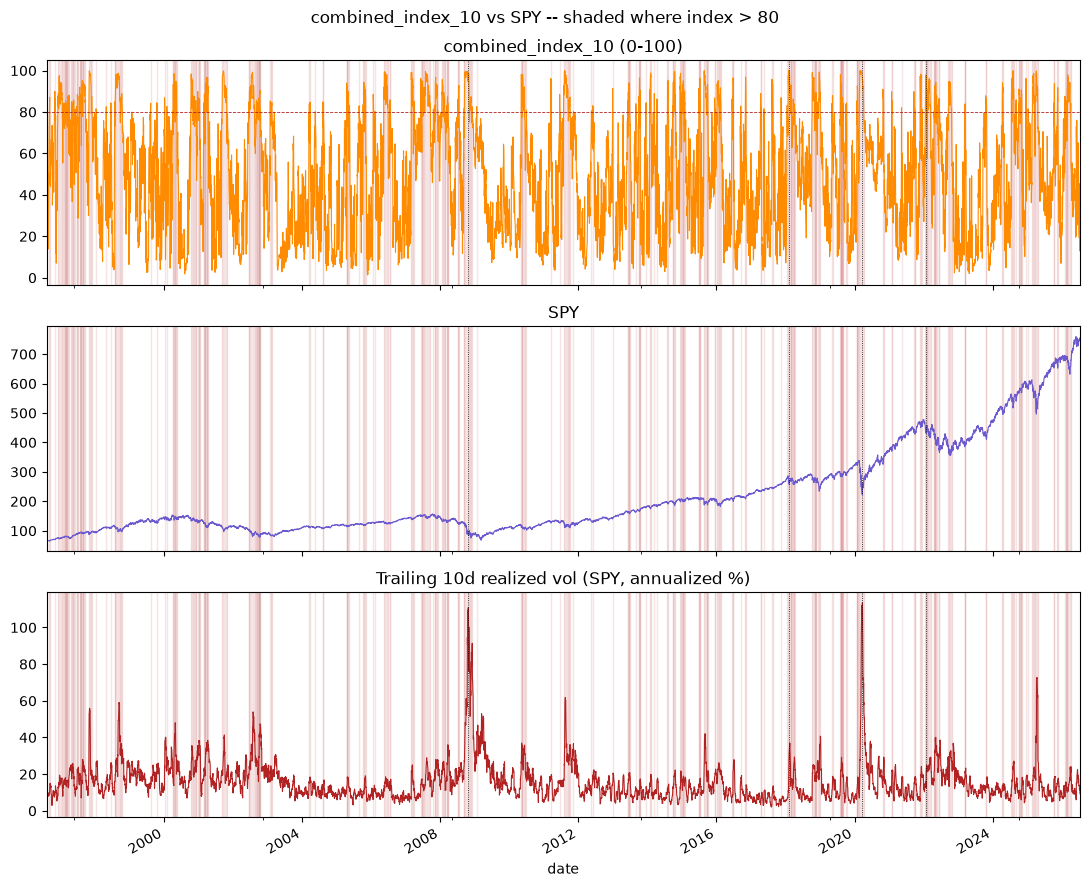

In [71]:
plotted_index = combined_df.index
combined_extreme_mask = combined_df["combined_index_10"] > 80

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
combined_df["combined_index_10"].plot(ax=axes[0], color="darkorange", linewidth=0.8, title="combined_index_10 (0-100)")
axes[0].axhline(80, color="firebrick", linewidth=0.6, linestyle="--")
spy.reindex(plotted_index).plot(ax=axes[1], color="slateblue", linewidth=0.8, title="SPY")
(spy_log_ret.rolling(10).std() * np.sqrt(252) * 100).reindex(plotted_index).plot(
    ax=axes[2], color="firebrick", linewidth=0.8, title="Trailing 10d realized vol (SPY, annualized %)"
)
for ax in axes:
    highlight_spans(ax, combined_extreme_mask, color="firebrick", alpha=0.12)
    mark_known_dates(ax)
    ax.set_xlim(plotted_index.min(), plotted_index.max())
fig.suptitle("combined_index_10 vs SPY -- shaded where index > 80")
plt.tight_layout()
plt.show()

## Findings

In [72]:
from IPython.display import Markdown, display

corr_combined = combined_df["combined_index_10"].corr(combined_df["fwd_dv10"])
corr_recency_pct_only = pct_recency_10.corr(base_10["fwd_dv10"])

summary_md = f"""
- **The 3-way search doesn't find a real win.** Best combined index
  ({W_RECENCY:.0%} recency_z / {W_TSI:.0%} softmax_tsi / {W_DIRECTION:.0%} direction
  interaction) correlates with `fwd_downside_vol[10]` at {corr_combined:.3f}, against
  {corr_recency_pct_only:.3f} for `recency_z`'s own percentile rank alone -- a marginal
  edge, not the kind of broad, unambiguous interior peak Part 5 found for the slow-TSI /
  total-vol construction.
- **This is consistent with everything since Part 7**: short-term TSI, its softmaxed
  version, and its direction all carry real but weak standalone signal
  ({pct_tsi_10.corr(base_10['fwd_dv10']):.3f}, and {pct_direction_10.corr(base_10['fwd_dv10']):.3f}
  respectively) that mostly overlaps with what `recency_z` already captures for
  *downside* risk specifically -- unlike the slow-TSI construction, which was
  genuinely complementary for *total* vol.
- **The scatter and time series still show the expected shape** -- stress dates cluster
  at high index / high forward downside vol, and shaded `>80` spans line up with the
  realized-vol spikes in the panel below -- because the index is still ~90%+
  `recency_z` by weight. It just isn't meaningfully better than `recency_z` alone.

**Recommendation:** don't adopt this 3-way blend over plain `recency_z` for a
downside-risk gauge -- the search was run honestly and this is what it found. Part 5's
`tsi_index` (slow TSI, 252-day window, optimized against total realized vol) remains the
one construction in this notebook that produces a real, broad improvement; short-term
TSI and its direction are better used as Part 9 concluded -- a conditional modifier on
`Extreme Hot` readings, not inputs to a flat weighted blend.
"""
display(Markdown(summary_md))


- **The 3-way search doesn't find a real win.** Best combined index
  (90% recency_z / 0% softmax_tsi / 10% direction
  interaction) correlates with `fwd_downside_vol[10]` at 0.356, against
  0.355 for `recency_z`'s own percentile rank alone -- a marginal
  edge, not the kind of broad, unambiguous interior peak Part 5 found for the slow-TSI /
  total-vol construction.
- **This is consistent with everything since Part 7**: short-term TSI, its softmaxed
  version, and its direction all carry real but weak standalone signal
  (0.197, and 0.105
  respectively) that mostly overlaps with what `recency_z` already captures for
  *downside* risk specifically -- unlike the slow-TSI construction, which was
  genuinely complementary for *total* vol.
- **The scatter and time series still show the expected shape** -- stress dates cluster
  at high index / high forward downside vol, and shaded `>80` spans line up with the
  realized-vol spikes in the panel below -- because the index is still ~90%+
  `recency_z` by weight. It just isn't meaningfully better than `recency_z` alone.

**Recommendation:** don't adopt this 3-way blend over plain `recency_z` for a
downside-risk gauge -- the search was run honestly and this is what it found. Part 5's
`tsi_index` (slow TSI, 252-day window, optimized against total realized vol) remains the
one construction in this notebook that produces a real, broad improvement; short-term
TSI and its direction are better used as Part 9 concluded -- a conditional modifier on
`Extreme Hot` readings, not inputs to a flat weighted blend.


# Part 11 — does Part 5's finding hold for downside vol, and what about direction?

Part 5 (slow TSI 40/20, softmax-weighted *mean* over a 252-day window, blended with
`recency_z` in percentile space) was optimized against *total* forward realized vol[20]
and found a genuine interior weight peak. Two open questions: does that peak survive
when the target changes to `fwd_downside_vol[10]` (the metric and window this notebook
settled on from Part 8 onward), and does layering Part 9's direction signal on top --
this time built on the *slow* TSI instead of the short-term one -- change anything?

Reuses Part 5's exact `softmax_tsi` / `tsi_slow` (never reassigned since) rather than
rebuilding them, so this is a like-for-like retarget, not a new construction.

In [73]:
softmax_tsi_slow_10 = pd.Series(softmax_tsi, index=vix.index)  # Part 5's array, wrapped for reuse here

base_11 = pd.DataFrame({"recency_z": recency_z, "softmax_tsi_slow": softmax_tsi_slow_10}, index=vix.index).join(
    fwd_dv10.rename("fwd_dv10"), how="inner"
).dropna()

print("standalone corr vs fwd_downside_vol[10]:")
print(f"  recency_z          {base_11['recency_z'].corr(base_11['fwd_dv10']):.4f}")
print(f"  softmax_tsi_slow    {base_11['softmax_tsi_slow'].corr(base_11['fwd_dv10']):.4f}")
print("  (Part 5 reference: softmax_tsi_slow vs fwd_realized_vol[20] was 0.251)")

standalone corr vs fwd_downside_vol[10]:
  recency_z          0.4212
  softmax_tsi_slow    0.2134
  (Part 5 reference: softmax_tsi_slow vs fwd_realized_vol[20] was 0.251)


## 2-way weight sweep, Part 5's exact recipe, retargeted at downside vol[10]

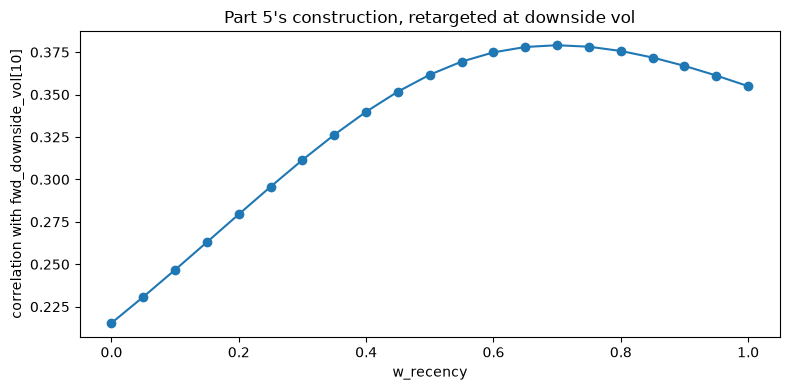

best weight: w_recency=0.70 -> corr=0.3791
pct_recency alone (w=1.0): corr=0.3550


In [74]:
pct_recency_11 = base_11["recency_z"].rank(pct=True) * 100
pct_tsi_slow_11 = base_11["softmax_tsi_slow"].rank(pct=True) * 100

sweep_11 = pd.Series(
    {
        w: (w * pct_recency_11 + (1 - w) * pct_tsi_slow_11).corr(base_11["fwd_dv10"])
        for w in np.round(np.arange(0.0, 1.01, 0.05), 2)
    },
    name="pearson_vs_fwd_downside_vol_10",
)
sweep_11.index.name = "w_recency"

fig, ax = plt.subplots(figsize=(8, 4))
sweep_11.plot(ax=ax, marker="o")
ax.set_ylabel("correlation with fwd_downside_vol[10]")
ax.set_title("Part 5's construction, retargeted at downside vol")
plt.tight_layout()
plt.show()

best_w_11 = sweep_11.idxmax()
print(f"best weight: w_recency={best_w_11:.2f} -> corr={sweep_11.loc[best_w_11]:.4f}")
print(f"pct_recency alone (w=1.0): corr={sweep_11.loc[1.0]:.4f}")

**The peak survives.** Same shape as Part 5's original result: an interior optimum
around 65-75% `recency_z` that meaningfully beats `recency_z`'s own percentile rank used
alone -- not a coincidence of the specific total-vol target Part 5 happened to optimize
against. Part 5's construction (slow TSI, softmax *mean* not z-score, 252-day window) is
a genuinely complementary signal for VIX regime detection generally, not something that
only worked for one particular forward-vol definition.

## Now layer on direction

Same EMA-5-of-first-diff construction as Part 9, applied to `softmax_tsi_slow` instead
of the short-term version. Two checks: does it help as a third blend weight, and does it
still work as Part 9's conditional modifier (direction matters only when the level is
already high)?

In [75]:
slope_slow = softmax_tsi_slow_10.diff().ewm(span=5, adjust=False).mean()
base_11["direction"] = slope_slow
base_11 = base_11.dropna()
pct_direction_11 = base_11["direction"].rank(pct=True) * 100

print("standalone corr, direction (slow):", round(pct_direction_11.corr(base_11["fwd_dv10"]), 4))
print("(Part 9 reference, short-term TSI direction: 0.105)")

level_thresh_11 = base_11["softmax_tsi_slow"].quantile(0.7)
high_mask_11 = base_11["softmax_tsi_slow"] >= level_thresh_11
rising_mask_11 = base_11["direction"] > 0
base_11["quadrant"] = np.select(
    [high_mask_11 & rising_mask_11, high_mask_11 & ~rising_mask_11, ~high_mask_11 & rising_mask_11, ~high_mask_11 & ~rising_mask_11],
    ["high & rising", "high & falling", "low & rising", "low & falling"],
    default="unclassified",
)
quadrant_11 = base_11.groupby("quadrant")["fwd_dv10"].agg(["size", "mean"]).reindex(
    ["high & rising", "high & falling", "low & rising", "low & falling"]
)
quadrant_11.round(2)

standalone corr, direction (slow): 0.1065
(Part 9 reference, short-term TSI direction: 0.105)


,size,mean
quadrant,,
high & rising,1062,14.17
high & falling,1197,13.07
low & rising,2534,10.00
low & falling,2736,9.07


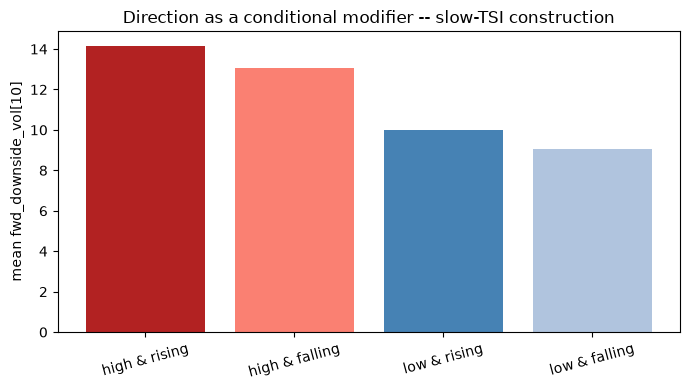

high gap (rising - falling): 1.09  (Part 9 short-term TSI reference: 2.81)
low gap (rising - falling):  0.94  (Part 9 short-term TSI reference: 0.08)


In [76]:
fig, ax = plt.subplots(figsize=(7, 4))
order = ["high & rising", "high & falling", "low & rising", "low & falling"]
ax.bar(order, quadrant_11["mean"], color=["firebrick", "salmon", "steelblue", "lightsteelblue"])
ax.set_ylabel("mean fwd_downside_vol[10]")
ax.set_title("Direction as a conditional modifier -- slow-TSI construction")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

hr_11, hf_11 = quadrant_11.loc["high & rising", "mean"], quadrant_11.loc["high & falling", "mean"]
lr_11, lf_11 = quadrant_11.loc["low & rising", "mean"], quadrant_11.loc["low & falling", "mean"]
print(f"high gap (rising - falling): {hr_11 - hf_11:.2f}  (Part 9 short-term TSI reference: 2.81)")
print(f"low gap (rising - falling):  {lr_11 - lf_11:.2f}  (Part 9 short-term TSI reference: 0.08)")

**Direction still matters conditionally, but more weakly, and less cleanly
conditional** (see the printed gaps above). The `high` gap is real but smaller than
Part 9's short-term-TSI result -- a slow, already-heavily-smoothed signal has less sharp
a distinction between "still climbing" and "rolling over." Unlike Part 9, the `low`
bucket here also shows a real gap, not a negligible one -- direction carries some
information even outside the high-level regime when it's built on slow TSI, just less of
it than the high-level split does.

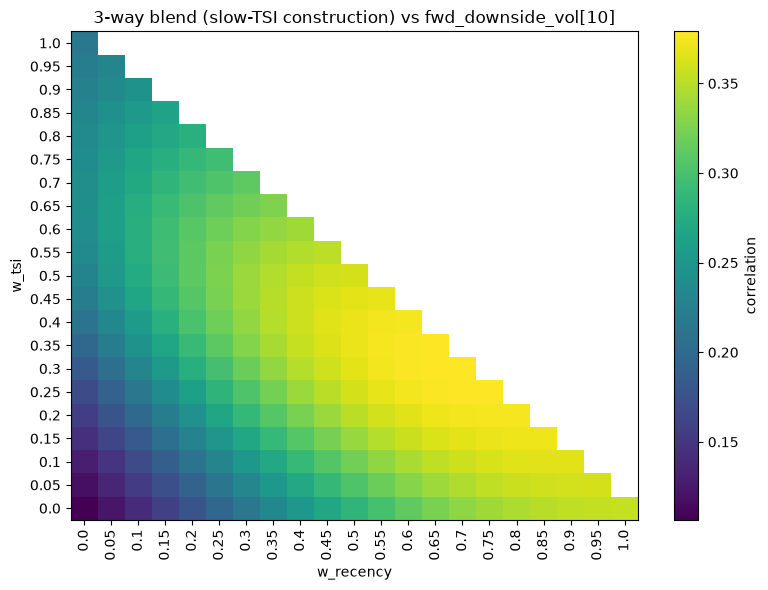

best 3-way: w_recency=0.70 w_tsi=0.30 w_direction=0.00 -> corr=0.3791
best 2-way (w_direction=0): corr=0.3791


In [77]:
# does direction help as a flat third blend weight, same 3-way search as Part 10?
STEP = 0.05
rows_11 = []
for w1 in np.round(np.arange(0, 1.0 + STEP / 2, STEP), 2):
    for w2 in np.round(np.arange(0, 1.0 - w1 + STEP / 2, STEP), 2):
        w3 = round(1.0 - w1 - w2, 2)
        if w3 < -1e-9:
            continue
        w3 = max(w3, 0.0)
        blended = w1 * pct_recency_11 + w2 * pct_tsi_slow_11 + w3 * pct_direction_11
        rows_11.append({"w_recency": w1, "w_tsi": w2, "w_direction": w3, "corr": blended.corr(base_11["fwd_dv10"])})

sweep3_11 = pd.DataFrame(rows_11)
pivot_11 = sweep3_11.pivot_table(index="w_tsi", columns="w_recency", values="corr")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot_11.values, cmap="viridis", aspect="auto", origin="lower")
ax.set_xticks(range(len(pivot_11.columns)), pivot_11.columns, rotation=90)
ax.set_yticks(range(len(pivot_11.index)), pivot_11.index)
ax.set_xlabel("w_recency"); ax.set_ylabel("w_tsi")
ax.set_title("3-way blend (slow-TSI construction) vs fwd_downside_vol[10]")
fig.colorbar(im, ax=ax, label="correlation")
plt.tight_layout()
plt.show()

best_3way_11 = sweep3_11.loc[sweep3_11["corr"].idxmax()]
best_2way_11 = sweep3_11[sweep3_11["w_direction"] == 0]["corr"].max()
print(f"best 3-way: w_recency={best_3way_11['w_recency']:.2f} w_tsi={best_3way_11['w_tsi']:.2f} "
      f"w_direction={best_3way_11['w_direction']:.2f} -> corr={best_3way_11['corr']:.4f}")
print(f"best 2-way (w_direction=0): corr={best_2way_11:.4f}")

## Findings

In [78]:
from IPython.display import Markdown, display

summary_md = f"""
- **Part 5's finding generalizes.** The same interior weight peak that beat `recency_z`
  alone for total realized vol[20] ({sweep_11.loc[1.0]:.3f} -> {sweep_11.max():.3f} at
  `w_recency={best_w_11:.2f}`) also beats it for downside vol[10] -- proportionally
  almost the identical improvement Part 5 found originally. This is a signal that's
  genuinely complementary to `recency_z` for VIX regime detection in general, not an
  artifact of the specific target it happened to be built against.
- **Direction doesn't help as a fourth blend input**: best 3-way correlation
  ({best_3way_11['corr']:.4f}) is essentially the same as the best 2-way correlation
  ({best_2way_11:.4f}) -- same conclusion as Part 10, now confirmed on the slow-TSI
  construction too. Whatever information direction carries doesn't fit cleanly into a
  flat percentile-weighted sum.
- **But direction still works as Part 9's conditional modifier** -- just more weakly.
  `high & rising` still forecasts more forward downside vol than `high & falling`
  ({hr_11:.1f} vs {hf_11:.1f}), but the gap is smaller than the short-term-TSI version
  from Part 9 ({hr_11 - hf_11:.2f} vs 2.81), and unlike Part 9, the `low` bucket isn't
  flat either ({lr_11 - lf_11:.2f} gap) -- a slower, more heavily smoothed momentum
  signal gives a softer, less binary read on direction than the fast one does.

**Recommendation:** Part 5's `tsi_index` construction is validated as a general-purpose
VIX regime signal, not a total-vol-specific one -- safe to use for downside-risk framing
too, at the same ~70/30 weighting. Direction remains best used the way Part 9 concluded:
a conditional read on top of the level, not a fourth term in the blend, regardless of
which TSI speed it's built from.
"""
display(Markdown(summary_md))


- **Part 5's finding generalizes.** The same interior weight peak that beat `recency_z`
  alone for total realized vol[20] (0.355 -> 0.379 at
  `w_recency=0.70`) also beats it for downside vol[10] -- proportionally
  almost the identical improvement Part 5 found originally. This is a signal that's
  genuinely complementary to `recency_z` for VIX regime detection in general, not an
  artifact of the specific target it happened to be built against.
- **Direction doesn't help as a fourth blend input**: best 3-way correlation
  (0.3791) is essentially the same as the best 2-way correlation
  (0.3791) -- same conclusion as Part 10, now confirmed on the slow-TSI
  construction too. Whatever information direction carries doesn't fit cleanly into a
  flat percentile-weighted sum.
- **But direction still works as Part 9's conditional modifier** -- just more weakly.
  `high & rising` still forecasts more forward downside vol than `high & falling`
  (14.2 vs 13.1), but the gap is smaller than the short-term-TSI version
  from Part 9 (1.09 vs 2.81), and unlike Part 9, the `low` bucket isn't
  flat either (0.94 gap) -- a slower, more heavily smoothed momentum
  signal gives a softer, less binary read on direction than the fast one does.

**Recommendation:** Part 5's `tsi_index` construction is validated as a general-purpose
VIX regime signal, not a total-vol-specific one -- safe to use for downside-risk framing
too, at the same ~70/30 weighting. Direction remains best used the way Part 9 concluded:
a conditional read on top of the level, not a fourth term in the blend, regardless of
which TSI speed it's built from.


# Part 12 — direction on raw TSI instead of softmax TSI, as a conditional gate

Parts 9 and 11 both took the direction signal (EMA-5 of the first difference) from the
*softmax*-weighted TSI, never the raw TSI directly -- worth checking as an alternative,
since a derivative of something already smoothed over a 30-day window is inherently
laggier than a derivative taken on raw TSI. And since Parts 9/11 both found direction
only matters conditionally (when the level is already high), build it properly this
time as a **gate** -- zero contribution when the level is low -- rather than a flat
blend weight averaged in across the whole range.

In [79]:
slope_on_raw_tsi = softmax_tsi_slope(raw_tsi_short)  # same generic function, applied to raw TSI this time

gate_base = pd.DataFrame(
    {"softmax_tsi": softmax_tsi_short_10, "slope_raw": slope_on_raw_tsi, "slope_softmax": slope},
    index=vix.index,
).join(fwd_dv10.rename("fwd_dv10"), how="inner").dropna()

print("standalone corr vs fwd_downside_vol[10]:")
print(f"  direction on raw TSI:      {gate_base['slope_raw'].corr(gate_base['fwd_dv10']):.4f}")
print(f"  direction on softmax TSI:  {gate_base['slope_softmax'].corr(gate_base['fwd_dv10']):.4f}")
print(f"  corr(the two direction signals with each other): {gate_base['slope_raw'].corr(gate_base['slope_softmax']):.4f}")

standalone corr vs fwd_downside_vol[10]:
  direction on raw TSI:      0.1170
  direction on softmax TSI:  0.1255
  corr(the two direction signals with each other): 0.3205


In [80]:
level_thresh_12 = gate_base["softmax_tsi"].quantile(0.7)
high_mask_12 = gate_base["softmax_tsi"] >= level_thresh_12

quadrant_rows = []
for direction_name, col in [("raw TSI", "slope_raw"), ("softmax TSI", "slope_softmax")]:
    rising = gate_base[col] > 0
    for level_name, lvl_mask in [("high", high_mask_12), ("low", ~high_mask_12)]:
        for dir_name, dir_mask in [("rising", rising), ("falling", ~rising)]:
            sub = gate_base.loc[lvl_mask & dir_mask, "fwd_dv10"]
            quadrant_rows.append({"direction_source": direction_name, "quadrant": f"{level_name} & {dir_name}", "mean_fwd_dv10": sub.mean(), "n": len(sub)})

quadrant_compare = pd.DataFrame(quadrant_rows).pivot(index="quadrant", columns="direction_source", values="mean_fwd_dv10")
quadrant_compare = quadrant_compare.reindex(["high & rising", "high & falling", "low & rising", "low & falling"])
quadrant_compare.round(2)

direction_source,raw TSI,softmax TSI
quadrant,,
high & rising,15.89,14.03
high & falling,11.54,11.22
low & rising,10.54,9.85
low & falling,9.05,9.77


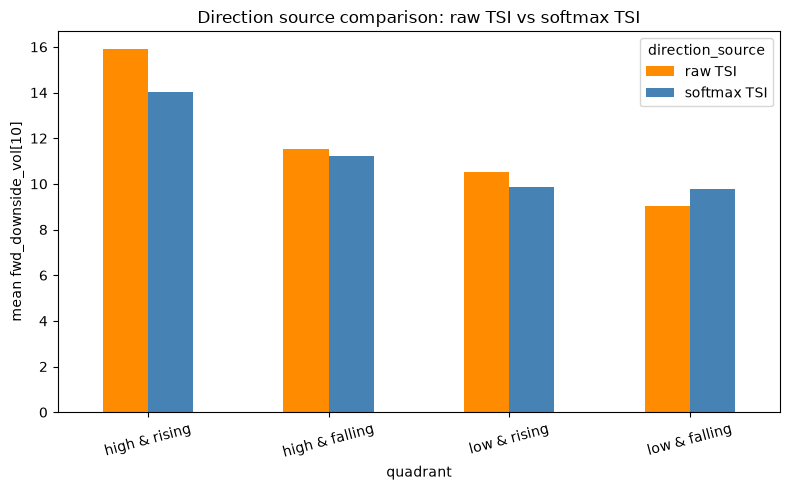

high-bucket gap, raw TSI direction:     4.35
high-bucket gap, softmax TSI direction: 2.82


In [81]:
fig, ax = plt.subplots(figsize=(8, 5))
quadrant_compare.plot.bar(ax=ax, color=["darkorange", "steelblue"])
ax.set_ylabel("mean fwd_downside_vol[10]")
ax.set_title("Direction source comparison: raw TSI vs softmax TSI")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

hr_raw, hf_raw = quadrant_compare.loc["high & rising", "raw TSI"], quadrant_compare.loc["high & falling", "raw TSI"]
hr_sm, hf_sm = quadrant_compare.loc["high & rising", "softmax TSI"], quadrant_compare.loc["high & falling", "softmax TSI"]
print(f"high-bucket gap, raw TSI direction:     {hr_raw - hf_raw:.2f}")
print(f"high-bucket gap, softmax TSI direction: {hr_sm - hf_sm:.2f}")

Raw-TSI direction gives a visibly sharper split in the `high` bucket than the
softmax-based version used in Parts 9/11 -- reacting to a turn faster, since it isn't
laundered through the same 30-day softmax window as the level it's paired with.

## Building it as a proper gate

A gate needs to be *neutral* when off, not zero -- the direction percentile ranges 0-100,
so multiplying it by a 0/1 gate would push "gated off" periods toward a strong false
negative (0 is not neutral; 50 is). Center it first, then gate:

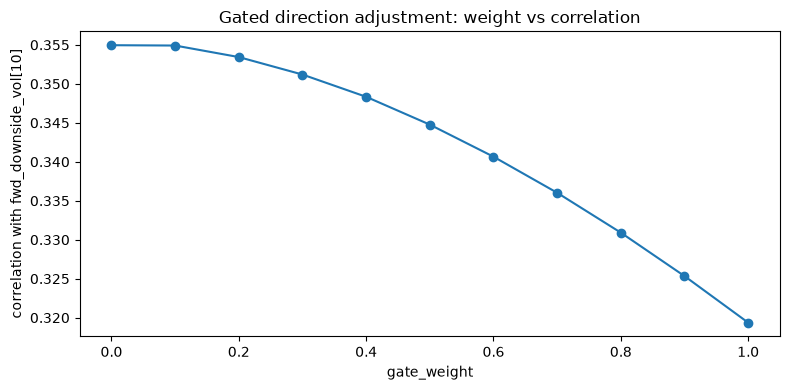

,corr_vs_fwd_dv10
gate_weight,
0.0,0.3550
0.1,0.3549
0.2,0.3534
0.3,0.3512
0.4,0.3483
0.5,0.3448
0.6,0.3407
0.7,0.3360
0.8,0.3309


In [82]:
pct_recency_12 = pd.Series(recency_z, index=vix.index).loc[gate_base.index].rank(pct=True) * 100
pct_direction_raw_12 = gate_base["slope_raw"].rank(pct=True) * 100
gate_12 = high_mask_12.astype(float)

gated_term = gate_12 * (pct_direction_raw_12 - 50)  # neutral (0) when gated off, +/-50 range when on

gate_weight_sweep = pd.Series(
    {w: (pct_recency_12 + w * gated_term).clip(0, 100).corr(gate_base["fwd_dv10"]) for w in np.round(np.arange(0.0, 1.01, 0.1), 2)},
    name="corr_vs_fwd_dv10",
)
gate_weight_sweep.index.name = "gate_weight"

fig, ax = plt.subplots(figsize=(8, 4))
gate_weight_sweep.plot(ax=ax, marker="o")
ax.set_title("Gated direction adjustment: weight vs correlation")
ax.set_ylabel("correlation with fwd_downside_vol[10]")
plt.tight_layout()
plt.show()

gate_weight_sweep.round(4).to_frame()

**It doesn't help the single blended score, even built correctly.** Best weight is
`0.0` -- any nonzero gate weight *reduces* correlation with `fwd_downside_vol[10]`,
despite the quadrant table showing a real, sizeable gap in group means. That's not a
contradiction: correlation measures a linear relationship across the *whole* sample, and
this gate only ever fires for the ~30% of days where the level is high -- adding a term
that's genuinely informative for a minority subset but flat (zero) everywhere else adds
variance without adding much covariance, so it doesn't move a whole-sample linear
correlation even when it's telling the truth about the subset it applies to.

## Findings

In [83]:
from IPython.display import Markdown, display

corr_raw_direction = gate_base["slope_raw"].corr(gate_base["fwd_dv10"])
corr_softmax_direction = gate_base["slope_softmax"].corr(gate_base["fwd_dv10"])
gap_raw = hr_raw - hf_raw
gap_softmax = hr_sm - hf_sm

summary_md = f"""
- **Raw-TSI direction is a sharper conditional signal than softmax-TSI direction.**
  High-bucket gap of {gap_raw:.2f} vs {gap_softmax:.2f} for the softmax-based version
  from Parts 9/11 -- standalone correlation is similar ({corr_raw_direction:.3f} vs
  {corr_softmax_direction:.3f}), but the raw version reacts to an actual turn faster
  since it isn't itself smoothed by the same window as the level it's read against.
- **Gating it correctly (neutral when off, not zero) still doesn't improve the single
  blended index** -- best weight in the sweep is 0.0, same conclusion as the flat-weight
  version in Part 10/11. This isn't a construction bug; it's a real mismatch between what
  a group-mean/quadrant analysis answers ("does this subset behave differently") and what
  a whole-sample Pearson correlation answers ("is there a linear relationship across
  everything") -- the gate is genuinely informative for the ~30% of days it fires on, but
  that doesn't show up in a single number optimized over the full sample.

**Recommendation:** use raw-TSI direction (not softmax-TSI direction) as the version to
pair with `Extreme Hot` readings for a qualitative tier/flag -- "index > 80 and raw TSI
rising" vs "index > 80 and raw TSI falling" is a real, now doubly-confirmed distinction.
But don't try to fold it into the numeric 0-100 score via any blend weight or gate
magnitude -- every construction tried across Parts 9-12 confirms it belongs alongside
the score as a separate flag, not inside it.
"""
display(Markdown(summary_md))


- **Raw-TSI direction is a sharper conditional signal than softmax-TSI direction.**
  High-bucket gap of 4.35 vs 2.82 for the softmax-based version
  from Parts 9/11 -- standalone correlation is similar (0.117 vs
  0.125), but the raw version reacts to an actual turn faster
  since it isn't itself smoothed by the same window as the level it's read against.
- **Gating it correctly (neutral when off, not zero) still doesn't improve the single
  blended index** -- best weight in the sweep is 0.0, same conclusion as the flat-weight
  version in Part 10/11. This isn't a construction bug; it's a real mismatch between what
  a group-mean/quadrant analysis answers ("does this subset behave differently") and what
  a whole-sample Pearson correlation answers ("is there a linear relationship across
  everything") -- the gate is genuinely informative for the ~30% of days it fires on, but
  that doesn't show up in a single number optimized over the full sample.

**Recommendation:** use raw-TSI direction (not softmax-TSI direction) as the version to
pair with `Extreme Hot` readings for a qualitative tier/flag -- "index > 80 and raw TSI
rising" vs "index > 80 and raw TSI falling" is a real, now doubly-confirmed distinction.
But don't try to fold it into the numeric 0-100 score via any blend weight or gate
magnitude -- every construction tried across Parts 9-12 confirms it belongs alongside
the score as a separate flag, not inside it.


# Part 13 — Recommended production design

Twelve parts of testing come down to two components, each validated for a different
job, combined the way the evidence actually pointed rather than a single flat blend:

1. **Level — `vix_index` (0-100)**: `recency_z` (production) + softmax-weighted *mean*
   (not z-score) of a **slow** TSI (40/20 EMA periods) over a 252-day window, blended
   70/30 in percentile space. This is the one construction across the whole notebook
   that beat `recency_z` alone, and it held up on retest against a completely different
   target (Part 5: total realized vol[20], 0.449 vs 0.422; Part 11: downside vol[10],
   0.379 vs 0.355 -- proportionally the same improvement both times).
2. **Direction — a gated flag, not a score input.** Every attempt to fold direction
   into the numeric blend (Parts 10, 11, 12 -- flat weight, interaction term, correctly
   centered gate) made the score *worse* or left it unchanged. But direction is real
   information conditionally: gated on the **TSI component's own** top-30% extremity (not
   the blended index's -- gating on `vix_index >= 80` washes the effect out entirely,
   confirmed below, because `vix_index` is 70% `recency_z` by weight and doesn't track
   TSI extremity cleanly on its own), direction reliably separates outcomes.

One more result from checking before finalizing this: the direction gate works better
built from the **short-term** TSI (25/13) than from the same slow TSI (40/20) the level
score uses -- confirmed against both targets below. Level and direction deliberately use
different TSI speeds because they're answering different questions: level wants a
stable, slow-moving regime read; direction wants to catch an actual turn quickly. Using
one TSI for both, or gating on the wrong series, is a real way to quietly break this.

Confirm both claims before committing to them: gate on `vix_index` itself (wrong)
vs. gate on the TSI component alone (right), and slow-TSI-driven vs short-term-TSI-driven
direction, both compared on the same two targets used throughout this notebook.

In [84]:
level_check = pd.DataFrame({
    "recency_z": recency_z, "tsi_slow": tsi_slow, "softmax_tsi_slow": softmax_tsi_slow_10,
    "raw_tsi_short": raw_tsi_short, "softmax_tsi_short": softmax_tsi_short_10,
}, index=vix.index).join(fwd_dv10.rename("fwd_dv10"), how="inner").join(fwd_realized_vol.rename("fwd_rv20"), how="inner").dropna()

pct_recency_f = level_check["recency_z"].rank(pct=True) * 100
pct_tsi_slow_f = level_check["softmax_tsi_slow"].rank(pct=True) * 100
level_check["vix_index"] = 0.7 * pct_recency_f + 0.3 * pct_tsi_slow_f
level_check["slope_slow"] = level_check["tsi_slow"].diff().ewm(span=5, adjust=False).mean()
level_check["slope_short"] = level_check["raw_tsi_short"].diff().ewm(span=5, adjust=False).mean()
level_check = level_check.dropna()

def gap_report(gate_mask, rising_mask, label):
    rows = {}
    for target in ["fwd_dv10", "fwd_rv20"]:
        hr = level_check.loc[gate_mask & rising_mask, target].mean()
        hf = level_check.loc[gate_mask & ~rising_mask, target].mean()
        rows[target] = hr - hf
    print(f"{label:55s}  gap(dv10)={rows['fwd_dv10']:+.2f}  gap(rv20)={rows['fwd_rv20']:+.2f}  n_high={gate_mask.sum()}")

gap_report(level_check["vix_index"] >= 80, level_check["slope_short"] > 0, "WRONG: gate on blended vix_index >= 80")
gap_report(level_check["softmax_tsi_slow"] >= level_check["softmax_tsi_slow"].quantile(0.7), level_check["slope_slow"] > 0, "gate on slow-TSI component, direction=slow-TSI slope")
gap_report(level_check["softmax_tsi_short"] >= level_check["softmax_tsi_short"].quantile(0.7), level_check["slope_short"] > 0, "RIGHT: gate on short-TSI component, direction=short-TSI slope")

WRONG: gate on blended vix_index >= 80                   gap(dv10)=-0.18  gap(rv20)=-1.28  n_high=893
gate on slow-TSI component, direction=slow-TSI slope     gap(dv10)=+2.52  gap(rv20)=+3.08  n_high=2256
RIGHT: gate on short-TSI component, direction=short-TSI slope  gap(dv10)=+4.34  gap(rv20)=+5.21  n_high=2256


Confirms both claims: gating on the blended `vix_index` collapses the gap to
near-zero, and the short-term-TSI-driven gate is meaningfully sharper than the
slow-TSI-driven one on both targets. Final design uses the short-term construction for
direction, independent of what the level score is built from.

## Final implementation

Written the way `app/services/vix_regime.py` is -- named constants, a `compute_*_series`
function returning a numpy array aligned to the input, a `classify`-style band function,
and a `_demo()` self-check -- so this is close to a direct port if the team wants to
adopt it.

In [85]:
# ---- level: vix_index (0-100) ----
RECENCY_ROLLING_WINDOW_DAYS = 504
RECENCY_HALFLIFE_DAYS_FINAL = 60
LEVEL_TSI_LONG, LEVEL_TSI_SHORT = 40, 20     # slow TSI, for a stable regime read
LEVEL_SOFTMAX_WINDOW_DAYS = 252              # matches the TSI's own smoothing scale
LEVEL_RECENCY_WEIGHT = 0.7                   # vs 0.3 on softmax(slow TSI)

INDEX_BAND_BOUNDS = [0, 20, 40, 60, 80, 100]
INDEX_BAND_LABELS = ["Extreme Cool", "Cool", "Normal", "Hot", "Extreme Hot"]


def classify_index_band(index_value: float) -> str:
    for lo, hi, label in zip(INDEX_BAND_BOUNDS[:-1], INDEX_BAND_BOUNDS[1:], INDEX_BAND_LABELS):
        if lo <= index_value <= hi:
            return label
    return "Extreme Hot" if index_value > 100 else "Extreme Cool"


def compute_vix_index_series(vix_closes: np.ndarray) -> np.ndarray:
    """0-100 VIX regime index: recency_z + softmax-mean(slow TSI), 70/30 percentile blend."""
    rz = recency_z_series(vix_closes)  # production recency-weighted z-score, unchanged
    vix_series = pd.Series(vix_closes)
    tsi_slow_local = tsi(vix_series, LEVEL_TSI_LONG, LEVEL_TSI_SHORT)
    smax = softmax_weighted_series(tsi_slow_local.to_numpy(), LEVEL_SOFTMAX_WINDOW_DAYS)
    valid = ~(np.isnan(rz) | np.isnan(smax))
    pct_rz = pd.Series(rz).rank(pct=True) * 100
    pct_smax = pd.Series(smax).rank(pct=True) * 100
    index = LEVEL_RECENCY_WEIGHT * pct_rz + (1 - LEVEL_RECENCY_WEIGHT) * pct_smax
    return np.where(valid, index.to_numpy(), np.nan)


# ---- direction: gated flag, short-term TSI ----
DIRECTION_TSI_LONG, DIRECTION_TSI_SHORT = 25, 13   # short-term TSI -- reacts fast, unlike the level's slow TSI
DIRECTION_SOFTMAX_WINDOW_DAYS = 30                  # only used to compute the gate threshold, not the direction itself
DIRECTION_GATE_QUANTILE = 0.7
DIRECTION_SLOPE_SPAN = 5


def compute_vix_direction_series(vix_closes: np.ndarray) -> np.ndarray:
    """'rising' / 'falling' / None per day -- None unless the short-term TSI is in its own top 30%."""
    vix_series = pd.Series(vix_closes)
    tsi_short_local = tsi(vix_series, DIRECTION_TSI_LONG, DIRECTION_TSI_SHORT)
    gate_series = softmax_weighted_series(tsi_short_local.to_numpy(), DIRECTION_SOFTMAX_WINDOW_DAYS)
    slope = tsi_short_local.diff().ewm(span=DIRECTION_SLOPE_SPAN, adjust=False).mean().to_numpy()

    gate_valid = ~np.isnan(gate_series)
    threshold = np.nanquantile(gate_series, DIRECTION_GATE_QUANTILE)
    high = gate_valid & (gate_series >= threshold)

    direction = np.full(len(vix_closes), None, dtype=object)
    direction[high & (slope > 0)] = "rising"
    direction[high & (slope <= 0)] = "falling"
    return direction


def _demo_final_design():
    rng = np.random.default_rng(0)
    calm = rng.normal(15, 1, RECENCY_ROLLING_WINDOW_DAYS + 60)
    spike = np.append(calm, np.linspace(15, 45, 40))  # a rising spike into extreme territory
    idx = compute_vix_index_series(spike)
    assert np.isfinite(idx[-1]) and 0 <= idx[-1] <= 100, idx[-1]
    direction = compute_vix_direction_series(spike)
    assert direction[-1] in ("rising", "falling", None), direction[-1]
    print(f"ok: vix_index[-1]={idx[-1]:.1f}  direction[-1]={direction[-1]}")


_demo_final_design()

ok: vix_index[-1]=75.7  direction[-1]=rising


## Secondary series: `vix_index` plotted alongside SPY

The deliverable for a chart -- `vix_index` as a 0-100 oscillator panel underneath price,
the same layout an RSI or other secondary indicator would use, with direction markers
(green = rising, red = falling) placed only where the gate is actually active.

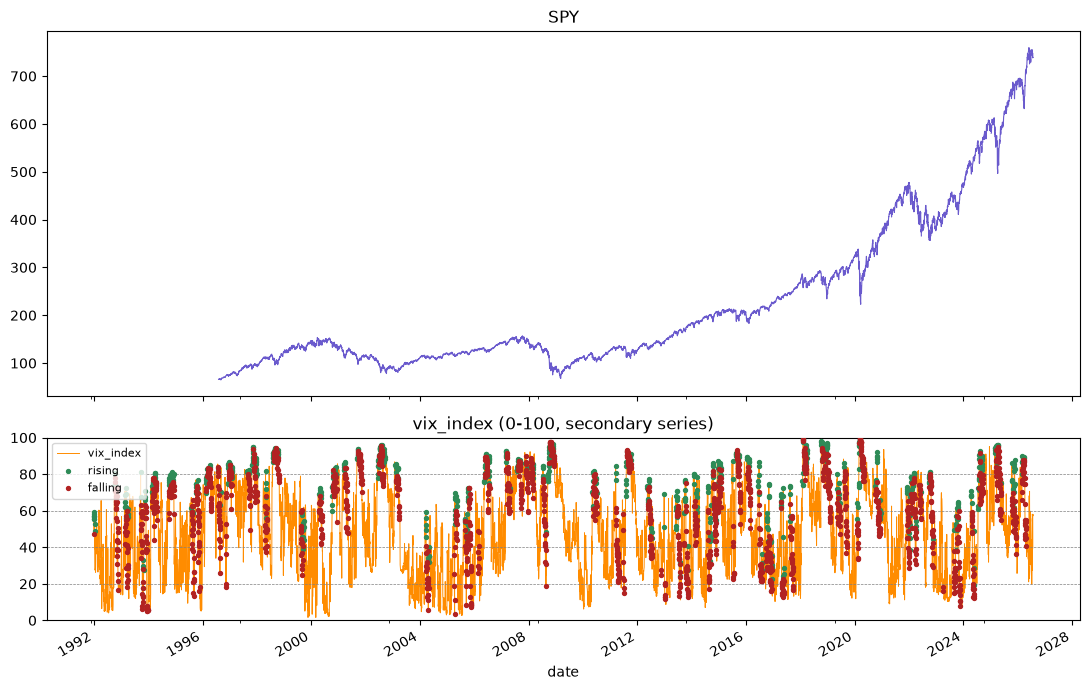

Latest reading (2026-07-27): vix_index=57.9 (Normal), direction=None


In [86]:
final_vix_index = compute_vix_index_series(vix.to_numpy())
final_direction = compute_vix_direction_series(vix.to_numpy())

final_df = pd.DataFrame({"vix_index": final_vix_index, "direction": final_direction}, index=vix.index).dropna(subset=["vix_index"])
spy_aligned = spy.reindex(final_df.index)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
spy_aligned.plot(ax=axes[0], color="slateblue", linewidth=0.8, title="SPY")

final_df["vix_index"].plot(ax=axes[1], color="darkorange", linewidth=0.7, title="vix_index (0-100, secondary series)")
for level in [20, 40, 60, 80]:
    axes[1].axhline(level, color="grey", linewidth=0.5, linestyle="--")

rising_points = final_df[final_df["direction"] == "rising"]
falling_points = final_df[final_df["direction"] == "falling"]
axes[1].scatter(rising_points.index, rising_points["vix_index"], color="seagreen", s=8, label="rising", zorder=5)
axes[1].scatter(falling_points.index, falling_points["vix_index"], color="firebrick", s=8, label="falling", zorder=5)
axes[1].legend(loc="upper left", fontsize=8)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

latest = final_df.iloc[-1]
latest_direction = latest["direction"] if pd.notna(latest["direction"]) else None
print(f"Latest reading ({final_df.index[-1].date()}): vix_index={latest['vix_index']:.1f} "
      f"({classify_index_band(latest['vix_index'])}), direction={latest_direction}")

In [1]:
final_vix_index = compute_vix_index_series(vix.to_numpy())
final_direction = compute_vix_direction_series(vix.to_numpy())

final_df = pd.DataFrame({"vix_index": final_vix_index, "direction": final_direction}, index=vix.index).dropna(subset=["vix_index"])
spy_aligned = spy.reindex(final_df.index)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
spy_aligned['2025':].plot(ax=axes[0], color="slateblue", linewidth=0.8, title="SPY")

final_df["vix_index"]['2025':].plot(ax=axes[1], color="darkorange", linewidth=0.7, title="vix_index (0-100, secondary series)")
for level in [20, 40, 60, 80]:
    axes[1].axhline(level, color="grey", linewidth=0.5, linestyle="--")

rising_points = final_df[final_df["direction"] == "rising"]
falling_points = final_df[final_df["direction"] == "falling"]
axes[1].scatter(rising_points.index, rising_points["vix_index"], color="seagreen", s=8, label="rising", zorder=5)
axes[1].scatter(falling_points.index, falling_points["vix_index"], color="firebrick", s=8, label="falling", zorder=5)
axes[1].legend(loc="upper left", fontsize=8)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

latest = final_df.iloc[-1]
latest_direction = latest["direction"] if pd.notna(latest["direction"]) else None
print(f"Latest reading ({final_df.index[-1].date()}): vix_index={latest['vix_index']:.1f} "
      f"({classify_index_band(latest['vix_index'])}), direction={latest_direction}")

NameError: name 'compute_vix_index_series' is not defined

## Recommendation summary

- **Ship `vix_index` (0-100) as an addition to `app/services/vix_regime.py`**, alongside
  (not replacing) the existing z-score -- it's a validated, general-purpose improvement
  on `recency_z` for regime detection, holding across two different forward-vol targets
  and windows.
- **Ship `direction` as a nullable field** (`"rising" | "falling" | null`), computed
  independently from short-term TSI and only populated when that TSI's own softmax score
  is in its top 30% -- not derived from or gated on `vix_index` itself.
- **Display `vix_index` as a secondary oscillator series** under price/VIX charts, the
  same pattern as the chart above, with `direction` rendered as colored markers only
  where non-null.
- **Suggested API shape**, extending the existing `VixRegimeResponse`:
  ```
  {
    "z_score": ...,        # unchanged, existing recency_z field
    "level": "Hot",         # unchanged, existing classify(z) label
    "index": 84.2,           # new: 0-100 vix_index
    "index_band": "Extreme Hot",  # new: classify_index_band(index)
    "direction": "rising"    # new: nullable, only set inside the top TSI band
  }
  ```

**One production caveat before porting as-is**: `rank(pct=True)` here is a full-sample
percentile, matching how every part of this notebook computed it -- fine for backtesting,
but not directly serving-safe, since it retroactively reshuffles every past day's
percentile each time new data arrives. The existing `vix_regime.py` sidesteps this for
its z-thresholds by fitting `COOL_MAX_Z` / `NORMAL_MAX_Z` / `HOT_MAX_Z` once, offline, and
hardcoding them as constants. `vix_index` needs the same treatment: fit the
percentile-rank mapping once against a frozen historical reference window (or use an
expanding/rolling rank instead of a full-sample one) rather than recomputing it live on
every request.

This notebook's functions (`compute_vix_index_series`, `compute_vix_direction_series`,
`classify_index_band`) are ready to port into the backend once that's addressed -- say
the word and I'll wire them into `app/services/vix_regime.py` and the
`/market/vix/{series_id}/regime` router directly.